# FDP Post-Training Survey Analysis
**Faculty Development Program – Post-Training Evaluation**  

---

In [ ]:
# ==============================================================================
# CELL 1. MOUNT GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ==============================================================================
# CELL 2. INSTALL REQUIRED PACKAGES
# ==============================================================================
!pip install wordcloud openpyxl scipy --quiet


In [ ]:
# ==============================================================================
# CELL 3. IMPORT LIBRARIES
# ==============================================================================
import os, warnings, textwrap
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import ttest_ind
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"]      = 150
plt.rcParams["font.family"]     = "DejaVu Sans"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)
print("Libraries loaded successfully.")


Libraries loaded successfully.


In [ ]:
# ==============================================================================
# CELL 4. DEFINE FILE PATHS AND OUTPUT DIRECTORIES
# ==============================================================================
DATA_DIR      = "/content/drive/MyDrive/FDP Survey"
SURVEY_PATH   = os.path.join(DATA_DIR,
    "Faculty Development Program (FDP) Post-Training Evaluation Form (Responses) - Form responses 1.csv")
FACULTY_PATH  = os.path.join(DATA_DIR,
    "Consolidated List of Certified Faculty_WEN PH - FDP Facultywise Status.csv")
OUTPUT_DIR    = os.path.join(DATA_DIR, "outputs")
CHART_DIR     = os.path.join(OUTPUT_DIR, "charts")
REPORT_DIR    = os.path.join(OUTPUT_DIR, "reports")

for folder in [CHART_DIR, REPORT_DIR]:
    os.makedirs(folder, exist_ok=True)

print("Paths configured.")
print("Checking files exist...")
import os as _os
for label, path in [("Survey", SURVEY_PATH), ("Faculty", FACULTY_PATH)]:
    exists = _os.path.isfile(path)
    print(f"  {label}: {'Found' if exists else 'NOT FOUND — check filename'} → {path}")

Paths configured.
Checking files exist...
  Survey: Found → /content/drive/MyDrive/FDP Survey/Faculty Development Program (FDP) Post-Training Evaluation Form (Responses) - Form responses 1.csv
  Faculty: Found → /content/drive/MyDrive/FDP Survey/Consolidated List of Certified Faculty_WEN PH - FDP Facultywise Status.csv


In [ ]:
# ==============================================================================
# CELL 5. LOAD BOTH DATA FILES
# ==============================================================================
df_survey  = pd.read_csv(SURVEY_PATH)
df_faculty = pd.read_csv(FACULTY_PATH)

print(f"Survey responses   : {df_survey.shape[0]} rows, {df_survey.shape[1]} columns")
print(f"Faculty master list: {df_faculty.shape[0]} rows, {df_faculty.shape[1]} columns")
print()
print("Survey columns:")
for i, c in enumerate(df_survey.columns, 1):
    print(f"  {i:>2}. {c}")


Survey responses   : 674 rows, 32 columns
Faculty master list: 1820 rows, 27 columns

Survey columns:
   1. Timestamp
   2. Email address
   3. Column 32
   4. Which Batch did you join?
   5. The Wadhwani Platform was easy to navigate.
   6. The learning modules in the Wadhwani Platform are well-organized and easy to follow.
   7. The lectures, readings, and assignments complemented each other.
   8. The instructional materials from the platform increased my knowledge and skills in the subject matter.
   9. The course workload and requirements were appropriate for the course level.
  10. The course assignments (Recorded Class demo, quizzes and Venture creation and submission) facilitated my learning.
  11. The instructor was well-prepared for the session.
  12. The instructor demonstrate a strong understanding of the subject matter.
  13. The instructor showed an interest in helping students learn.
  14. Presentation of the material was interesting and engaging.
  15. Made students fee

In [ ]:
# ==============================================================================
# CELL 6. DROP UNNECESSARY COLUMNS FROM SURVEY
# ==============================================================================
DROP_COLS = ["Column 32", "Full Name", "Email address", "Remarks"]
DROP_COLS = [c for c in DROP_COLS if c in df_survey.columns]
df_survey = df_survey.drop(columns=DROP_COLS)
print(f"Columns after removal: {df_survey.shape[1]}")


Columns after removal: 28


In [ ]:
# ==============================================================================
# CELL 7. PARSE TIMESTAMPS IN BOTH FILES
# ==============================================================================
df_survey["Timestamp"]               = pd.to_datetime(df_survey["Timestamp"], dayfirst=True, errors="coerce")
df_faculty["FDP start date"]         = pd.to_datetime(df_faculty["FDP start date"], errors="coerce")
df_faculty["FDP completion date"]    = pd.to_datetime(df_faculty["FDP completion date"], errors="coerce")
df_faculty["Course completed date"]  = pd.to_datetime(df_faculty["Course completed date"], errors="coerce")

print("Survey timestamp range:")
print(f"  Earliest : {df_survey['Timestamp'].min()}")
print(f"  Latest   : {df_survey['Timestamp'].max()}")
print()
print("Faculty FDP start date year distribution:")
print(df_faculty["FDP start date"].dt.year.value_counts().sort_index().to_string())
print()
print("Faculty FDP completion date year distribution:")
print(df_faculty["FDP completion date"].dt.year.value_counts().sort_index().to_string())


Survey timestamp range:
  Earliest : 2025-02-07 21:15:00
  Latest   : 2026-03-06 11:57:00

Faculty FDP start date year distribution:
FDP start date
2024.0     443
2025.0    1045
2026.0     299

Faculty FDP completion date year distribution:
FDP completion date
2024.0     208
2025.0    1228
2026.0     382


In [ ]:
# ==============================================================================
# CELL 8. BUILD BATCH-TO-YEAR MAPPING FROM FACULTY MASTER LIST
#
# Since many survey rows have no timestamp, we cross-reference the batch name
# in the survey against the faculty consolidated list to accurately assign each
# response to a training year (2024, 2025, or 2026).
#
# We use FDP completion date year as the reference year because:
#   - Some batches started in late 2024 but completed in early 2025
#   - The survey was filled out upon completion/certification
#   - Completion year best represents "when the training was experienced"
# ==============================================================================

BATCH_COL = "Which Batch did you join?"

# Build year map from faculty list using completion date
batch_year_map = (
    df_faculty.dropna(subset=["FDP completion date"])
    .groupby("Batch Name/Cohort Name")["FDP completion date"]
    .first()
    .dt.year
    .astype(int)
    .to_dict()
)

# Manual survey-batch → year mapping
# (Survey batch names don't always match faculty batch names exactly,
#  so we map them manually based on cross-referencing both files)
SURVEY_TO_YEAR = {
    "DOST Ignite Batch 1"         : 2025,
    "Nov Batch"                   : 2024,  # Ignite X_FDP_Nov_2024 → completed Jan 2025
    "Dec Batch"                   : 2025,  # FDP_IgniteX_Dec2024_Batch → completed Feb 2025
    "Refresher June 2025 Batch"   : 2025,
    "May 2025 Evening Session"    : 2025,
    "Refresher Batch"             : 2025,
    "FDP June 2025"               : 2025,
    "January 2025 Batch"          : 2025,
    "FDP CSU/CSUCC/FSUU BATCH"    : 2025,
    "DOST_Ignite_2025_Batch2"     : 2025,
    "FDP USTP 2025"               : 2025,
    "May 2025 9am-12nn session"   : 2025,
    "May-June 3-5 PM Session"     : 2025,
    "Refresher Jan Batch"         : 2025,
    "FDP Mindanao Refresher"      : 2025,
    "SNSU FDP"                    : 2025,
    "January Batch"               : 2025,
    "CSU/SCUCC FDP"               : 2025,
    "UA FDP"                      : 2025,
    "HTC FDP"                     : 2025,
    "NORSU FDP"                   : 2025,
    "FDP Iligan"                  : 2025,
    "FDP ADDU x PWC"              : 2025,
    "UM FDP"                      : 2025,
    "USTP"                        : 2025,
    "FDP Jan2026 (online)"        : 2026,
    "FDP_June2026_7-9PM"          : 2026,
    "FDP_June2026_2-4PM"          : 2026,
    "ISATU FDP"                   : 2026,
    "STI College"                 : 2026,
    "CAPSU FDP"                   : 2026,
    "ASU FDP"                     : 2026,
    "NISU FDP"                    : 2026,
    "GSU FDP"                     : 2026,
    "OWWA XII"                    : 2026,
    "MSEUF FDP"                   : 2026,
    "LPUM FDP"                    : 2026,
    "MAPUA FDP"                   : 2026,
}

def assign_period(row):
    ts    = row["Timestamp"]
    batch = str(row[BATCH_COL]).strip() if pd.notna(row[BATCH_COL]) else ""
    # Priority 1: valid timestamp
    if pd.notna(ts):
        return str(int(ts.year))
    # Priority 2: manual cross-reference mapping
    if batch in SURVEY_TO_YEAR:
        return str(SURVEY_TO_YEAR[batch])
    return "Unlabeled"

df_survey["Period"] = df_survey.apply(assign_period, axis=1)

print("=== Period Distribution After Cross-Referencing ===")
print(df_survey["Period"].value_counts().sort_index().to_string())
print()
print("Note: 'Unlabeled' rows have neither a timestamp nor a recognisable batch name.")
print(f"      These {(df_survey['Period']=='Unlabeled').sum()} rows will be excluded from year-over-year analysis only.")


=== Period Distribution After Cross-Referencing ===
Period
2024           6
2025         449
2026         216
Unlabeled      3

Note: 'Unlabeled' rows have neither a timestamp nor a recognisable batch name.
      These 3 rows will be excluded from year-over-year analysis only.


In [ ]:
# ==============================================================================
# CELL 9. DROP FULLY BLANK ROWS (no timestamp AND no batch name)
# ==============================================================================
before = len(df_survey)
df_survey = df_survey[~((df_survey["Timestamp"].isna()) & (df_survey[BATCH_COL].isna()))].reset_index(drop=True)
after = len(df_survey)
print(f"Rows removed (blank): {before - after}")
print(f"Rows remaining      : {after}")


Rows removed (blank): 3
Rows remaining      : 671


In [ ]:
# ==============================================================================
# CELL 10. DATA QUALITY CHECK — MISSING VALUES
# ==============================================================================
print("=== Missing Values per Column ===")
missing = df_survey.isnull().sum()
print(missing[missing > 0].to_string())
print()
print("=== Period Distribution (Final) ===")
print(df_survey["Period"].value_counts().sort_index().to_string())


=== Missing Values per Column ===
Timestamp                                                                                                                                    375
What were the best aspects of the FDP?                                                                                                        19
What else can we improve?                                                                                                                     41
Please write here if you have any more concerns, feedbacks, or suggestions that you think will help us do better for the future students.    431

=== Period Distribution (Final) ===
Period
2024      6
2025    449
2026    216


In [ ]:
# ==============================================================================
# CELL 11. DEFINE ANALYTICAL CONSTANTS
# ==============================================================================

SHORT_LABELS = {
    "The Wadhwani Platform was easy to navigate."                                                                          : "Platform Easy to Navigate",
    "The learning modules in the Wadhwani Platform are well-organized and easy to follow."                                 : "Modules Well-Organized",
    "The lectures, readings, and assignments complemented each other."                                                     : "Lectures/Readings/Assignments Complement",
    "The instructional materials from the platform increased my knowledge and skills in the subject matter."               : "Materials Increased Knowledge",
    "The course workload and requirements were appropriate for the course level."                                           : "Workload Appropriateness",
    "The course assignments (Recorded Class demo, quizzes and Venture creation and submission) facilitated my learning."   : "Assignments Facilitated Learning",
    "The instructor was well-prepared for the session."                                                                    : "Instructor Well-Prepared",
    "The instructor demonstrate a strong understanding of the subject matter."                                             : "Instructor Subject Mastery",
    "The instructor showed an interest in helping students learn."                                                         : "Instructor Interest in Students",
    "Presentation of the material was interesting and engaging."                                                           : "Engaging Presentation",
    "Made students feel free to ask questions."                                                                            : "Question-Friendly Environment",
    "I attend session regularly."                                                                                          : "Student Attendance",
    "I consistently prepared for session."                                                                                 : "Student Preparedness",
    "I have put a great deal of effort into advancing my learning in this course."                                         : "Student Learning Effort",
    "In this course, I have been challenged to learn more than I expected."                                                : "Challenged Beyond Expectations",
    "I had intellectual communication among my peers."                                                                     : "Peer Communication",
    "The facilitators were approachable and I feel comfortable to ask for assistance any time."                            : "Facilitators Accessibility",
    "I feel welcome and supported."                                                                                        : "Supportive Environment",
    "They make themselves available outside of the session hours to answer questions or provide support."                  : "Support Outside Sessions",
    "Overall, the facilitators were helpful."                                                                              : "Overall Facilitators Helpfulness",
    "I would highly recommend this program."                                                                               : "Program Recommendation",
    "This program had high educational impact."                                                                            : "High Educational Impact",
    "Overall, this course met my expectations."                                                                            : "Course Met Expectations",
}

CATEGORIES = {
    "Platform & Content": [
        "The Wadhwani Platform was easy to navigate.",
        "The learning modules in the Wadhwani Platform are well-organized and easy to follow.",
        "The lectures, readings, and assignments complemented each other.",
        "The instructional materials from the platform increased my knowledge and skills in the subject matter.",
        "The course workload and requirements were appropriate for the course level.",
        "The course assignments (Recorded Class demo, quizzes and Venture creation and submission) facilitated my learning.",
    ],
    "Instructor Quality": [
        "The instructor was well-prepared for the session.",
        "The instructor demonstrate a strong understanding of the subject matter.",
        "The instructor showed an interest in helping students learn.",
        "Presentation of the material was interesting and engaging.",
        "Made students feel free to ask questions.",
    ],
    "Student Engagement": [
        "I attend session regularly.",
        "I consistently prepared for session.",
        "I have put a great deal of effort into advancing my learning in this course.",
        "In this course, I have been challenged to learn more than I expected.",
        "I had intellectual communication among my peers.",
    ],
    "Facilitator Support": [
        "The facilitators were approachable and I feel comfortable to ask for assistance any time.",
        "I feel welcome and supported.",
        "They make themselves available outside of the session hours to answer questions or provide support.",
        "Overall, the facilitators were helpful.",
    ],
    "Overall Satisfaction": [
        "I would highly recommend this program.",
        "This program had high educational impact.",
        "Overall, this course met my expectations.",
    ],
}

PALETTE = {
    "Platform & Content"  : "#5DCAA5",
    "Instructor Quality"  : "#7F77DD",
    "Student Engagement"  : "#EF9F27",
    "Facilitator Support" : "#D85A30",
    "Overall Satisfaction": "#378ADD",
}

OPEN_ENDED = {
    "best_aspects": "What were the best aspects of the FDP?",
    "improvements": "What else can we improve?",
    "suggestions" : "Please write here if you have any more concerns, feedbacks, or suggestions that you think will help us do better for the future students.",
}

JUNK = {"none","none.","none so far","na","n/a","nothing","thank you","thank you!","","-","n.a.","no comment"," "}

RATING_COLS = list(SHORT_LABELS.keys())

q_category = {}
for cat, cols in CATEGORIES.items():
    for c in cols:
        q_category[c] = cat

print("Constants defined.")
print(f"  Likert items : {len(RATING_COLS)}")
print(f"  Categories   : {len(CATEGORIES)}")


Constants defined.
  Likert items : 23
  Categories   : 5


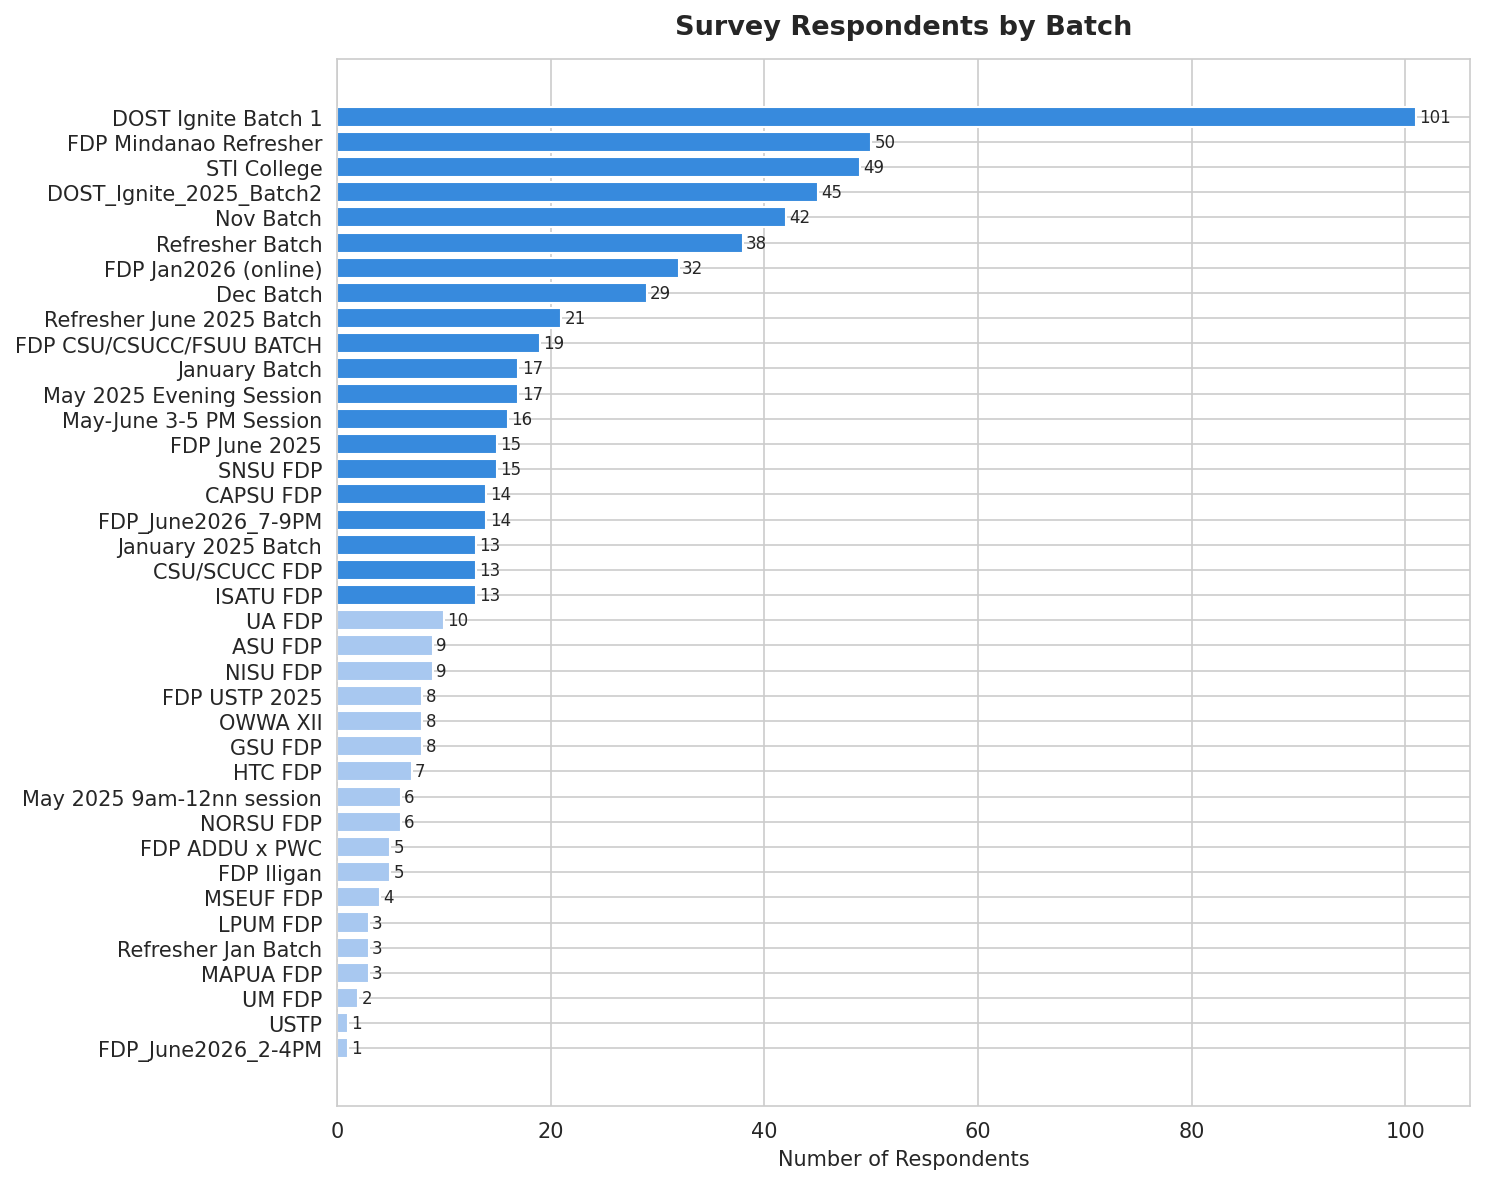

In [ ]:
# ==============================================================================
# CELL 12. RESPONDENT PROFILE — BATCH DISTRIBUTION
# ==============================================================================
batch_counts = (
    df_survey[BATCH_COL].value_counts()
    .reset_index()
    .rename(columns={BATCH_COL:"Batch","count":"Respondents"})
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#378ADD" if v >= batch_counts["Respondents"].median() else "#A8C8F0"
          for v in batch_counts["Respondents"]]
ax.barh(batch_counts["Batch"], batch_counts["Respondents"], color=colors, edgecolor="white")
for bar in ax.patches:
    w = bar.get_width()
    ax.text(w+0.3, bar.get_y()+bar.get_height()/2, str(int(w)), va="center", fontsize=8)
ax.set_xlabel("Number of Respondents", fontsize=10)
ax.set_title("Survey Respondents by Batch", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"01_respondents_by_batch.png"), dpi=300, bbox_inches="tight")
plt.show()


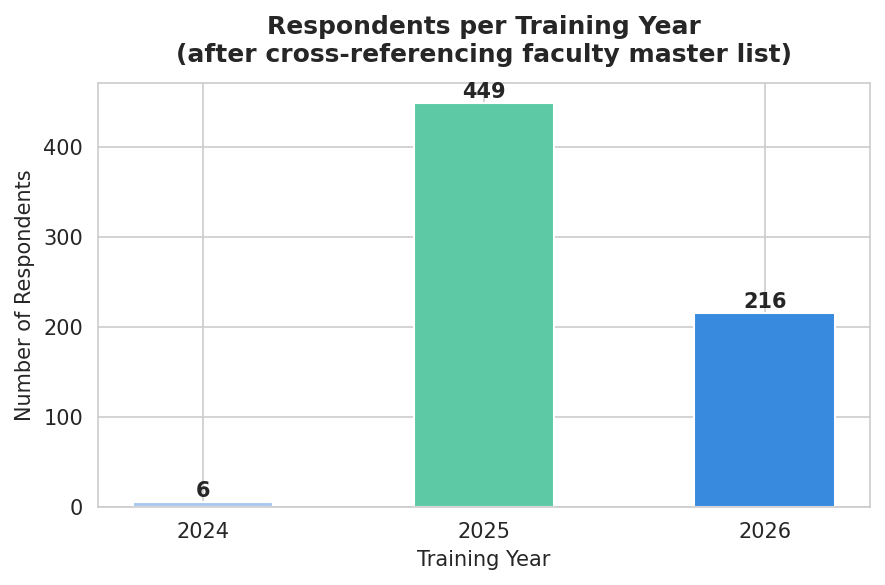

Training Year  Respondents
         2024            6
         2025          449
         2026          216


In [ ]:
# ==============================================================================
# CELL 13. RESPONDENT PROFILE — YEAR DISTRIBUTION
#
# Shows confirmed respondent counts per training year after cross-referencing
# the faculty master list. This replaces the old "Unlabeled" problem.
# ==============================================================================
period_counts = df_survey["Period"].value_counts().sort_index().reset_index()
period_counts.columns = ["Training Year", "Respondents"]

fig, ax = plt.subplots(figsize=(6, 4))
colors = {"2024":"#A8C8F0","2025":"#5DCAA5","2026":"#378ADD","Unlabeled":"#cccccc"}
bar_colors = [colors.get(str(p), "#cccccc") for p in period_counts["Training Year"]]
bars = ax.bar(period_counts["Training Year"].astype(str), period_counts["Respondents"],
              color=bar_colors, edgecolor="white", width=0.5)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+1, str(int(h)), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xlabel("Training Year", fontsize=10)
ax.set_ylabel("Number of Respondents", fontsize=10)
ax.set_title("Respondents per Training Year\n(after cross-referencing faculty master list)", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"02_respondents_by_year.png"), dpi=300, bbox_inches="tight")
plt.show()

print(period_counts.to_string(index=False))


In [ ]:
# ==============================================================================
# CELL 14. OVERALL DESCRIPTIVE STATISTICS
# ==============================================================================
q_mean   = df_survey[RATING_COLS].mean()
q_std    = df_survey[RATING_COLS].std()
q_median = df_survey[RATING_COLS].median()

question_summary = pd.DataFrame({
    "Category"   : [q_category.get(c,"—") for c in RATING_COLS],
    "Short Label": [SHORT_LABELS[c] for c in RATING_COLS],
    "Mean"       : q_mean.values.round(3),
    "Std Dev"    : q_std.values.round(3),
    "Median"     : q_median.values.round(1),
})

overall_mean = df_survey[RATING_COLS].mean().mean()
print(f"Overall Survey Average: {overall_mean:.3f} / 5.00")
print()
question_summary


Overall Survey Average: 4.692 / 5.00



,Category,Short Label,Mean,Std Dev,Median
0,Platform & Content,Platform Easy to Navigate,4.613,0.646,5.0
1,Platform & Content,Modules Well-Organized,4.663,0.623,5.0
2,Platform & Content,Lectures/Readings/Assignments Complement,4.717,0.576,5.0
3,Platform & Content,Materials Increased Knowledge,4.759,0.542,5.0
4,Platform & Content,Workload Appropriateness,4.638,0.654,5.0
5,Platform & Content,Assignments Facilitated Learning,4.668,0.617,5.0
6,Instructor Quality,Instructor Well-Prepared,4.750,0.507,5.0
7,Instructor Quality,Instructor Subject Mastery,4.770,0.505,5.0
8,Instructor Quality,Instructor Interest in Students,4.769,0.508,5.0
9,Instructor Quality,Engaging Presentation,4.683,0.593,5.0


In [ ]:
# ==============================================================================
# CELL 15. CATEGORY SCORES
# ==============================================================================
category_scores = {cat: df_survey[cols].mean().mean() for cat, cols in CATEGORIES.items()}
category_series = pd.Series(category_scores).sort_values(ascending=False)

category_table = pd.DataFrame({
    "Category"     : category_series.index,
    "Average Score": category_series.values.round(3),
})
print("Category Scores (highest to lowest):")
print(category_table.to_string(index=False))


Category Scores (highest to lowest):
            Category  Average Score
Overall Satisfaction          4.784
 Facilitator Support          4.770
  Instructor Quality          4.748
  Platform & Content          4.676
  Student Engagement          4.539


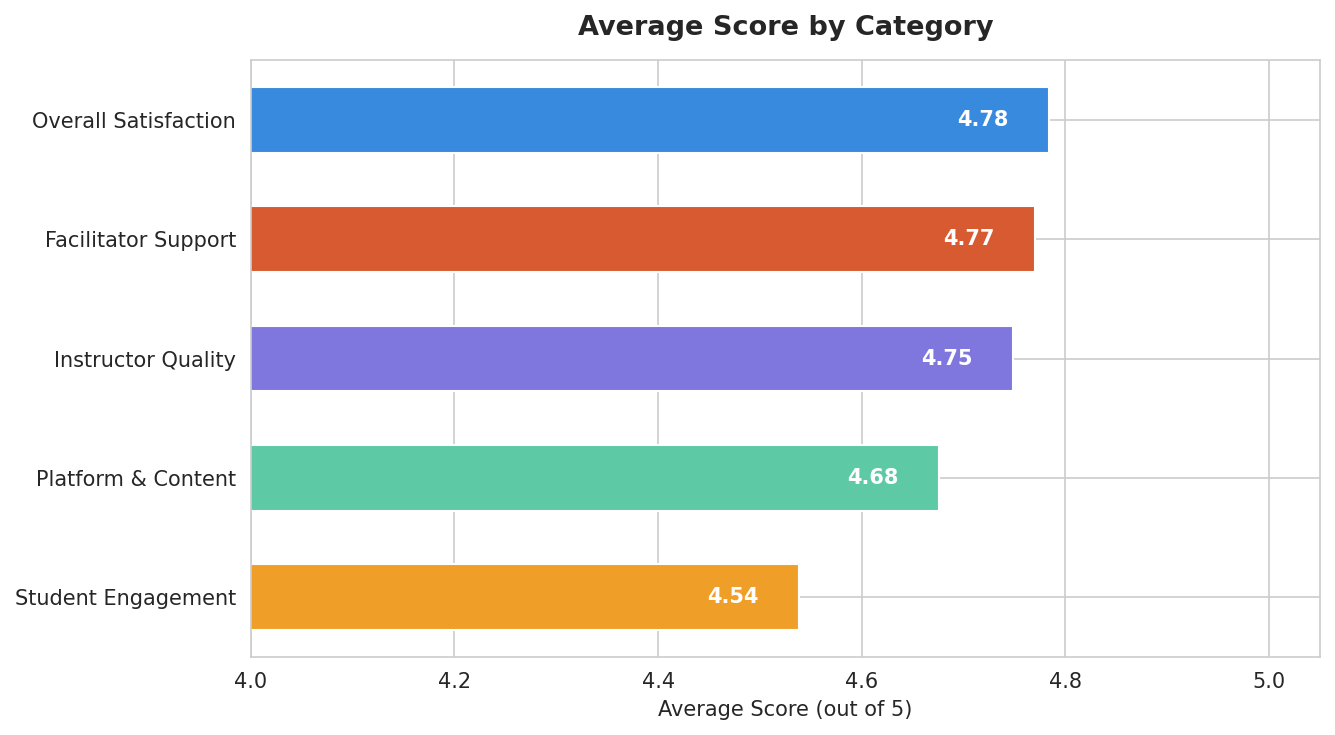

In [ ]:
# ==============================================================================
# CELL 16. CATEGORY SCORE BAR CHART
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = [PALETTE[c] for c in category_series.index]
bars = ax.barh(category_series.index, category_series.values, color=bar_colors, edgecolor="white", height=0.55)
for bar in bars:
    w = bar.get_width()
    ax.text(w-0.04, bar.get_y()+bar.get_height()/2, f"{w:.2f}",
            va="center", ha="right", color="white", fontweight="bold", fontsize=10)
ax.set_xlim(4.0, 5.05)
ax.set_xlabel("Average Score (out of 5)", fontsize=10)
ax.set_title("Average Score by Category", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"03_category_scores.png"), dpi=300, bbox_inches="tight")
plt.show()


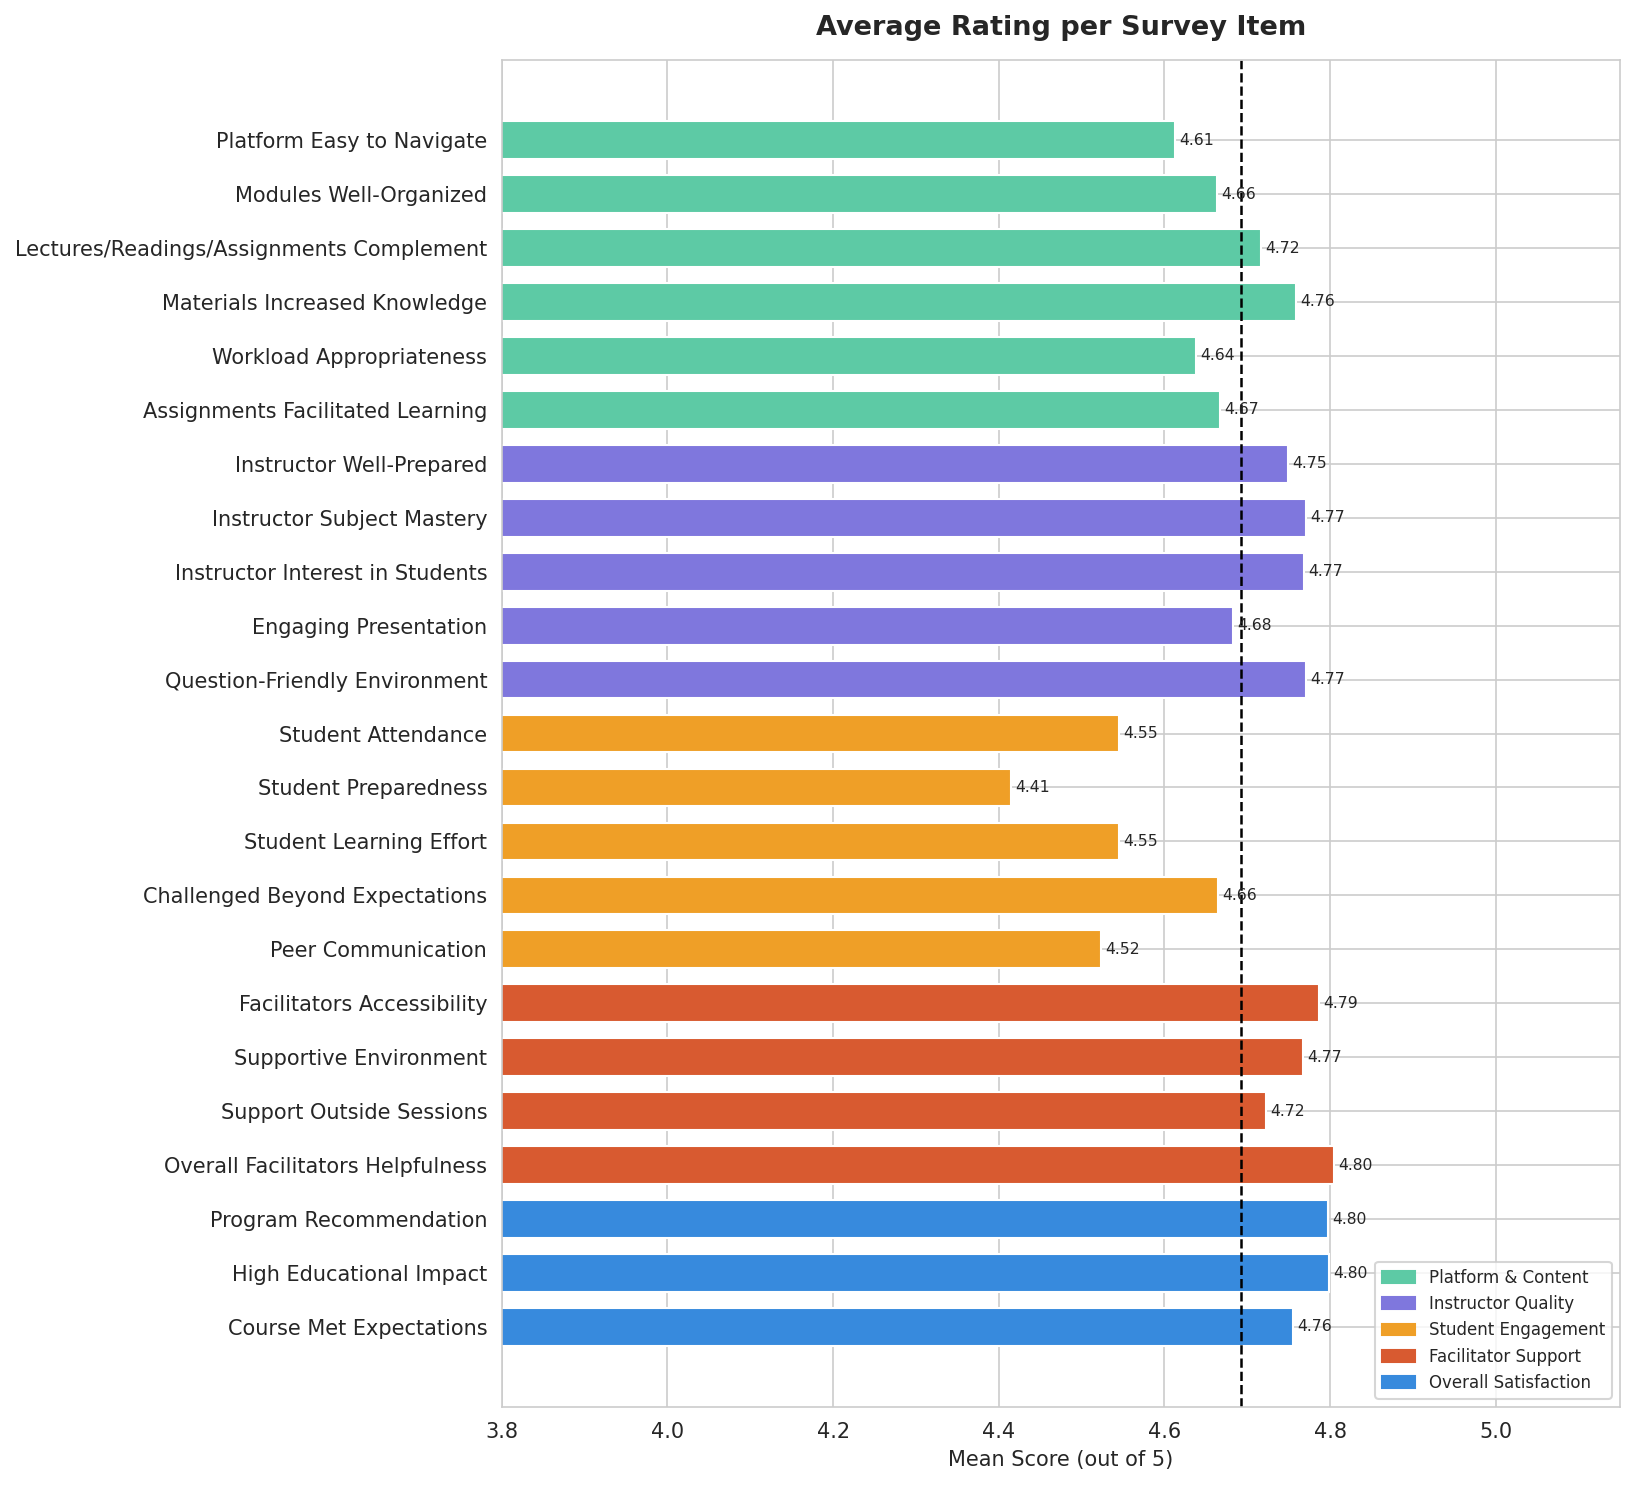

In [ ]:
# ==============================================================================
# CELL 17. ITEM-LEVEL MEAN BAR CHART (ALL 23 QUESTIONS)
# ==============================================================================
short_labels = [SHORT_LABELS[c] for c in RATING_COLS]
item_colors  = [PALETTE[q_category[c]] for c in RATING_COLS]
means        = [q_mean[c] for c in RATING_COLS]

fig, ax = plt.subplots(figsize=(11, 10))
ax.barh(short_labels, means, color=item_colors, edgecolor="white", height=0.7)
ax.axvline(overall_mean, color="black", linewidth=1.2, linestyle="--",
           label=f"Overall Mean = {overall_mean:.2f}")
for i, (label, m) in enumerate(zip(short_labels, means)):
    ax.text(m+0.005, i, f"{m:.2f}", va="center", fontsize=7.5)
legend_patches = [mpatches.Patch(color=v, label=k) for k,v in PALETTE.items()]
ax.legend(handles=legend_patches, loc="lower right", fontsize=8, framealpha=0.8)
ax.set_xlim(3.8, 5.15)
ax.set_xlabel("Mean Score (out of 5)", fontsize=10)
ax.set_title("Average Rating per Survey Item", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"04_item_means.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ==============================================================================
# CELL 18. TOP 5 STRENGTHS AND AREAS FOR IMPROVEMENT
# ==============================================================================
question_means = pd.Series({SHORT_LABELS[c]: q_mean[c] for c in RATING_COLS}).sort_values()

top_strengths = question_means.tail(5).reset_index()
top_strengths.columns = ["Strength","Mean Score"]
top_strengths["Mean Score"] = top_strengths["Mean Score"].round(3)
top_strengths = top_strengths.sort_values("Mean Score", ascending=False)

weaknesses = question_means.head(5).reset_index()
weaknesses.columns = ["Area for Improvement","Mean Score"]
weaknesses["Mean Score"] = weaknesses["Mean Score"].round(3)

print("Top 5 Strengths:")
print(top_strengths.to_string(index=False))
print()
print("Top 5 Areas for Improvement:")
print(weaknesses.to_string(index=False))


Top 5 Strengths:
                        Strength  Mean Score
Overall Facilitators Helpfulness       4.805
         High Educational Impact       4.799
          Program Recommendation       4.797
      Facilitators Accessibility       4.787
   Question-Friendly Environment       4.770

Top 5 Areas for Improvement:
     Area for Improvement  Mean Score
     Student Preparedness       4.414
       Peer Communication       4.523
  Student Learning Effort       4.545
       Student Attendance       4.545
Platform Easy to Navigate       4.613


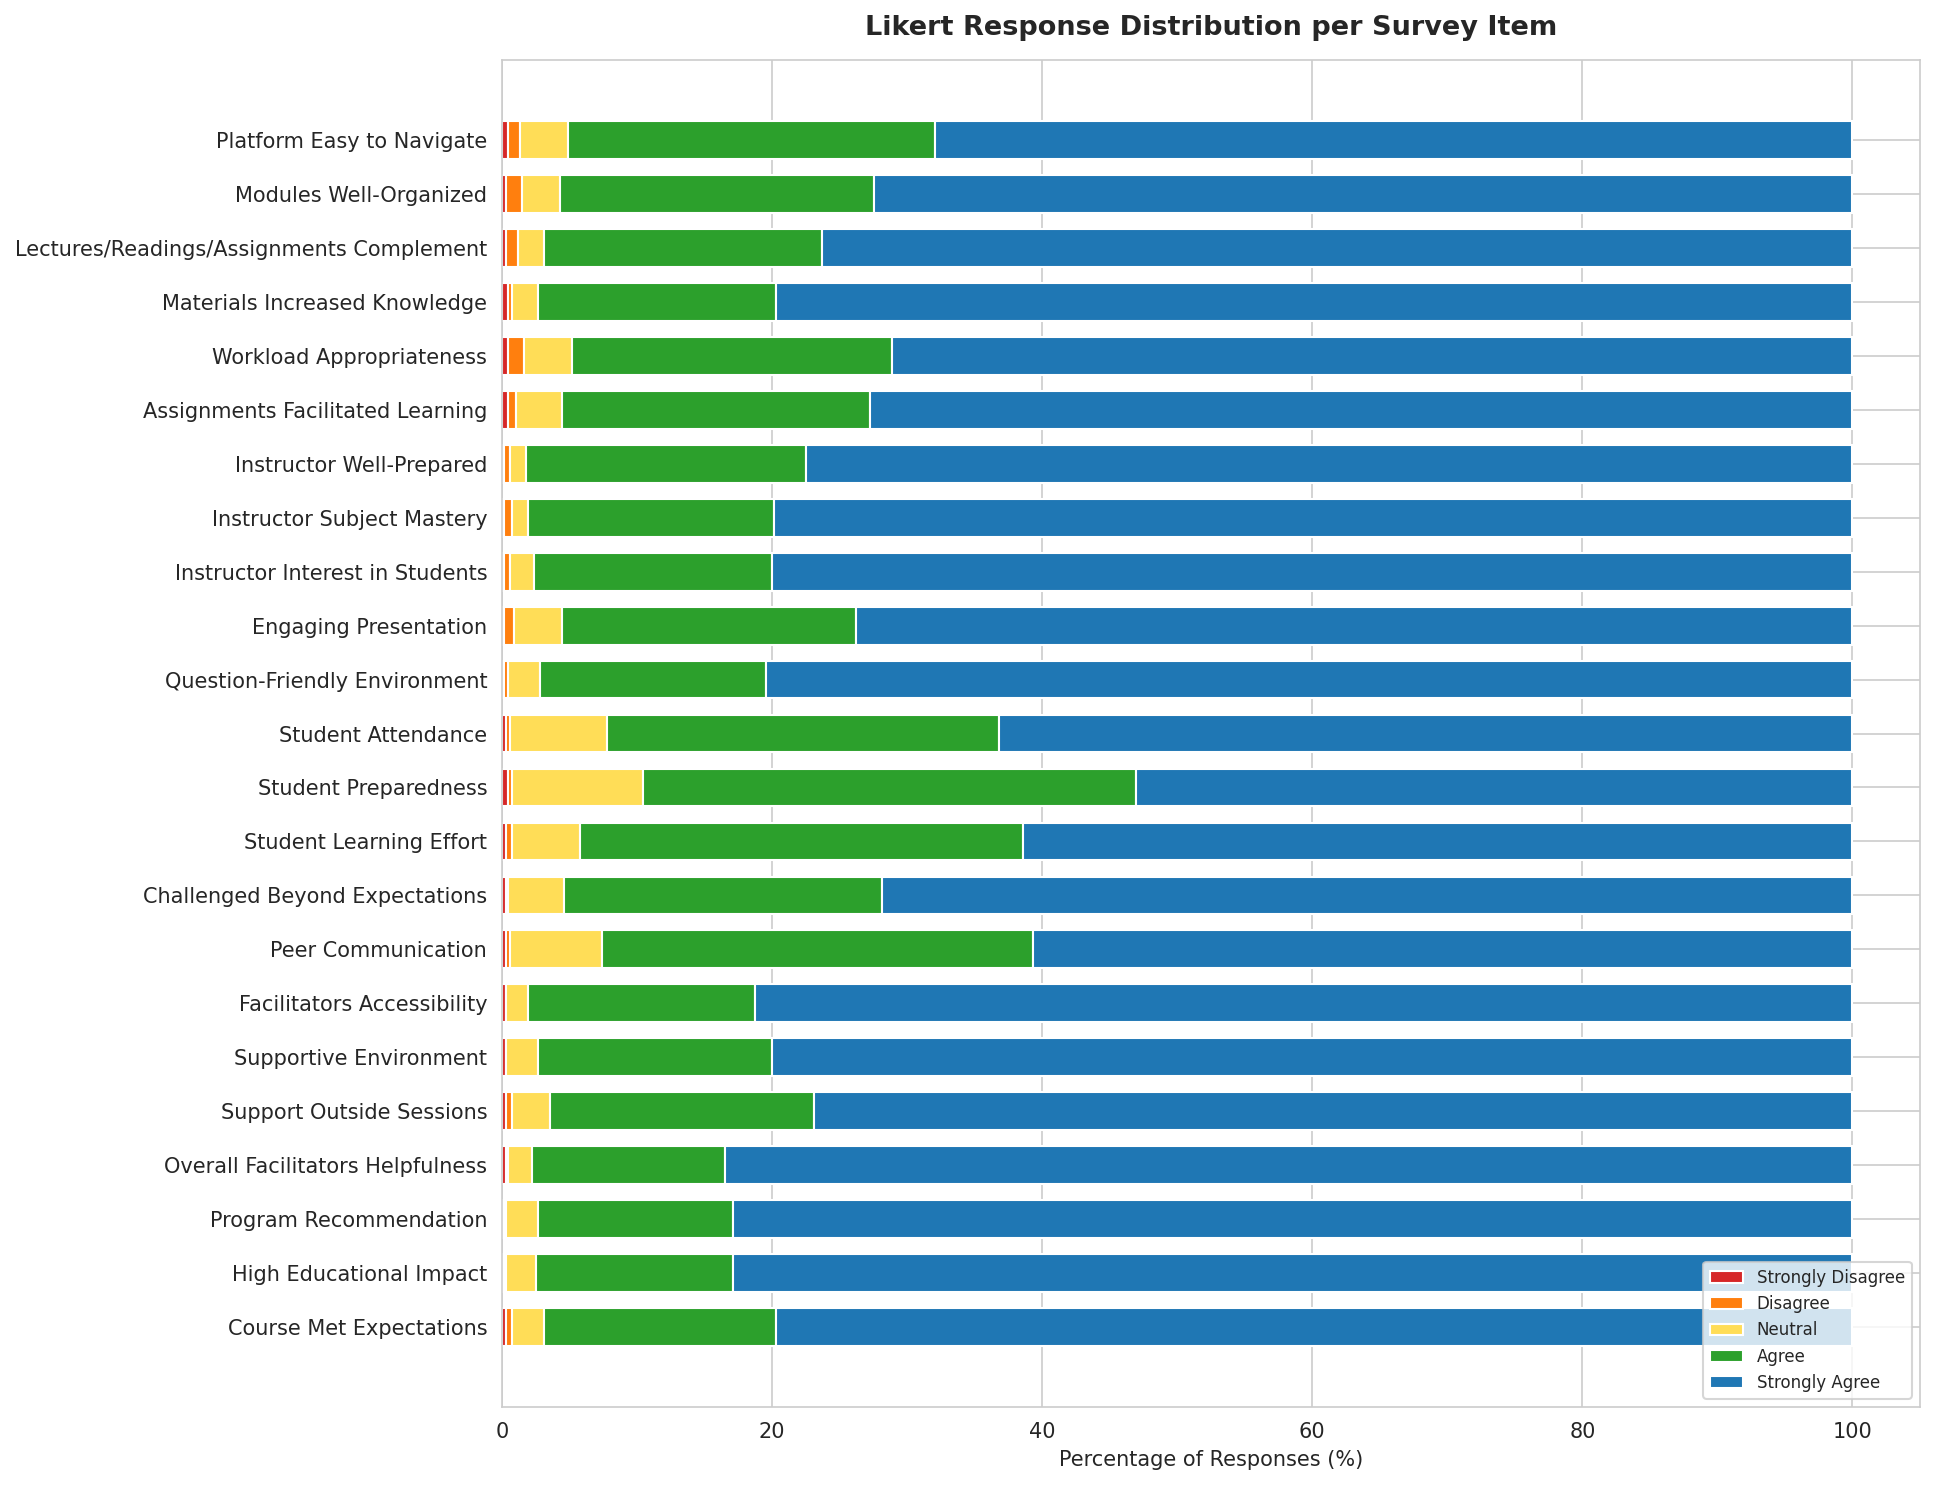

In [ ]:
# ==============================================================================
# CELL 19. LIKERT RESPONSE DISTRIBUTION STACKED BAR CHART
# ==============================================================================
LIKERT_COLORS = {1:"#D62728",2:"#FF7F0E",3:"#FFDD57",4:"#2CA02C",5:"#1F77B4"}
LIKERT_LABELS = {1:"Strongly Disagree",2:"Disagree",3:"Neutral",4:"Agree",5:"Strongly Agree"}

pct_df = pd.DataFrame(index=[SHORT_LABELS[c] for c in RATING_COLS])
for score in [1,2,3,4,5]:
    pct_df[LIKERT_LABELS[score]] = [
        (df_survey[c]==score).sum()/df_survey[c].notna().sum()*100 for c in RATING_COLS
    ]

fig, ax = plt.subplots(figsize=(13, 10))
left = np.zeros(len(pct_df))
for score in [1,2,3,4,5]:
    label = LIKERT_LABELS[score]
    ax.barh(pct_df.index, pct_df[label], left=left,
            color=LIKERT_COLORS[score], label=label, edgecolor="white", height=0.7)
    left += pct_df[label].values
ax.set_xlabel("Percentage of Responses (%)", fontsize=10)
ax.set_title("Likert Response Distribution per Survey Item", fontsize=13, fontweight="bold", pad=12)
ax.legend(loc="lower right", fontsize=8, framealpha=0.8)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"05_likert_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()


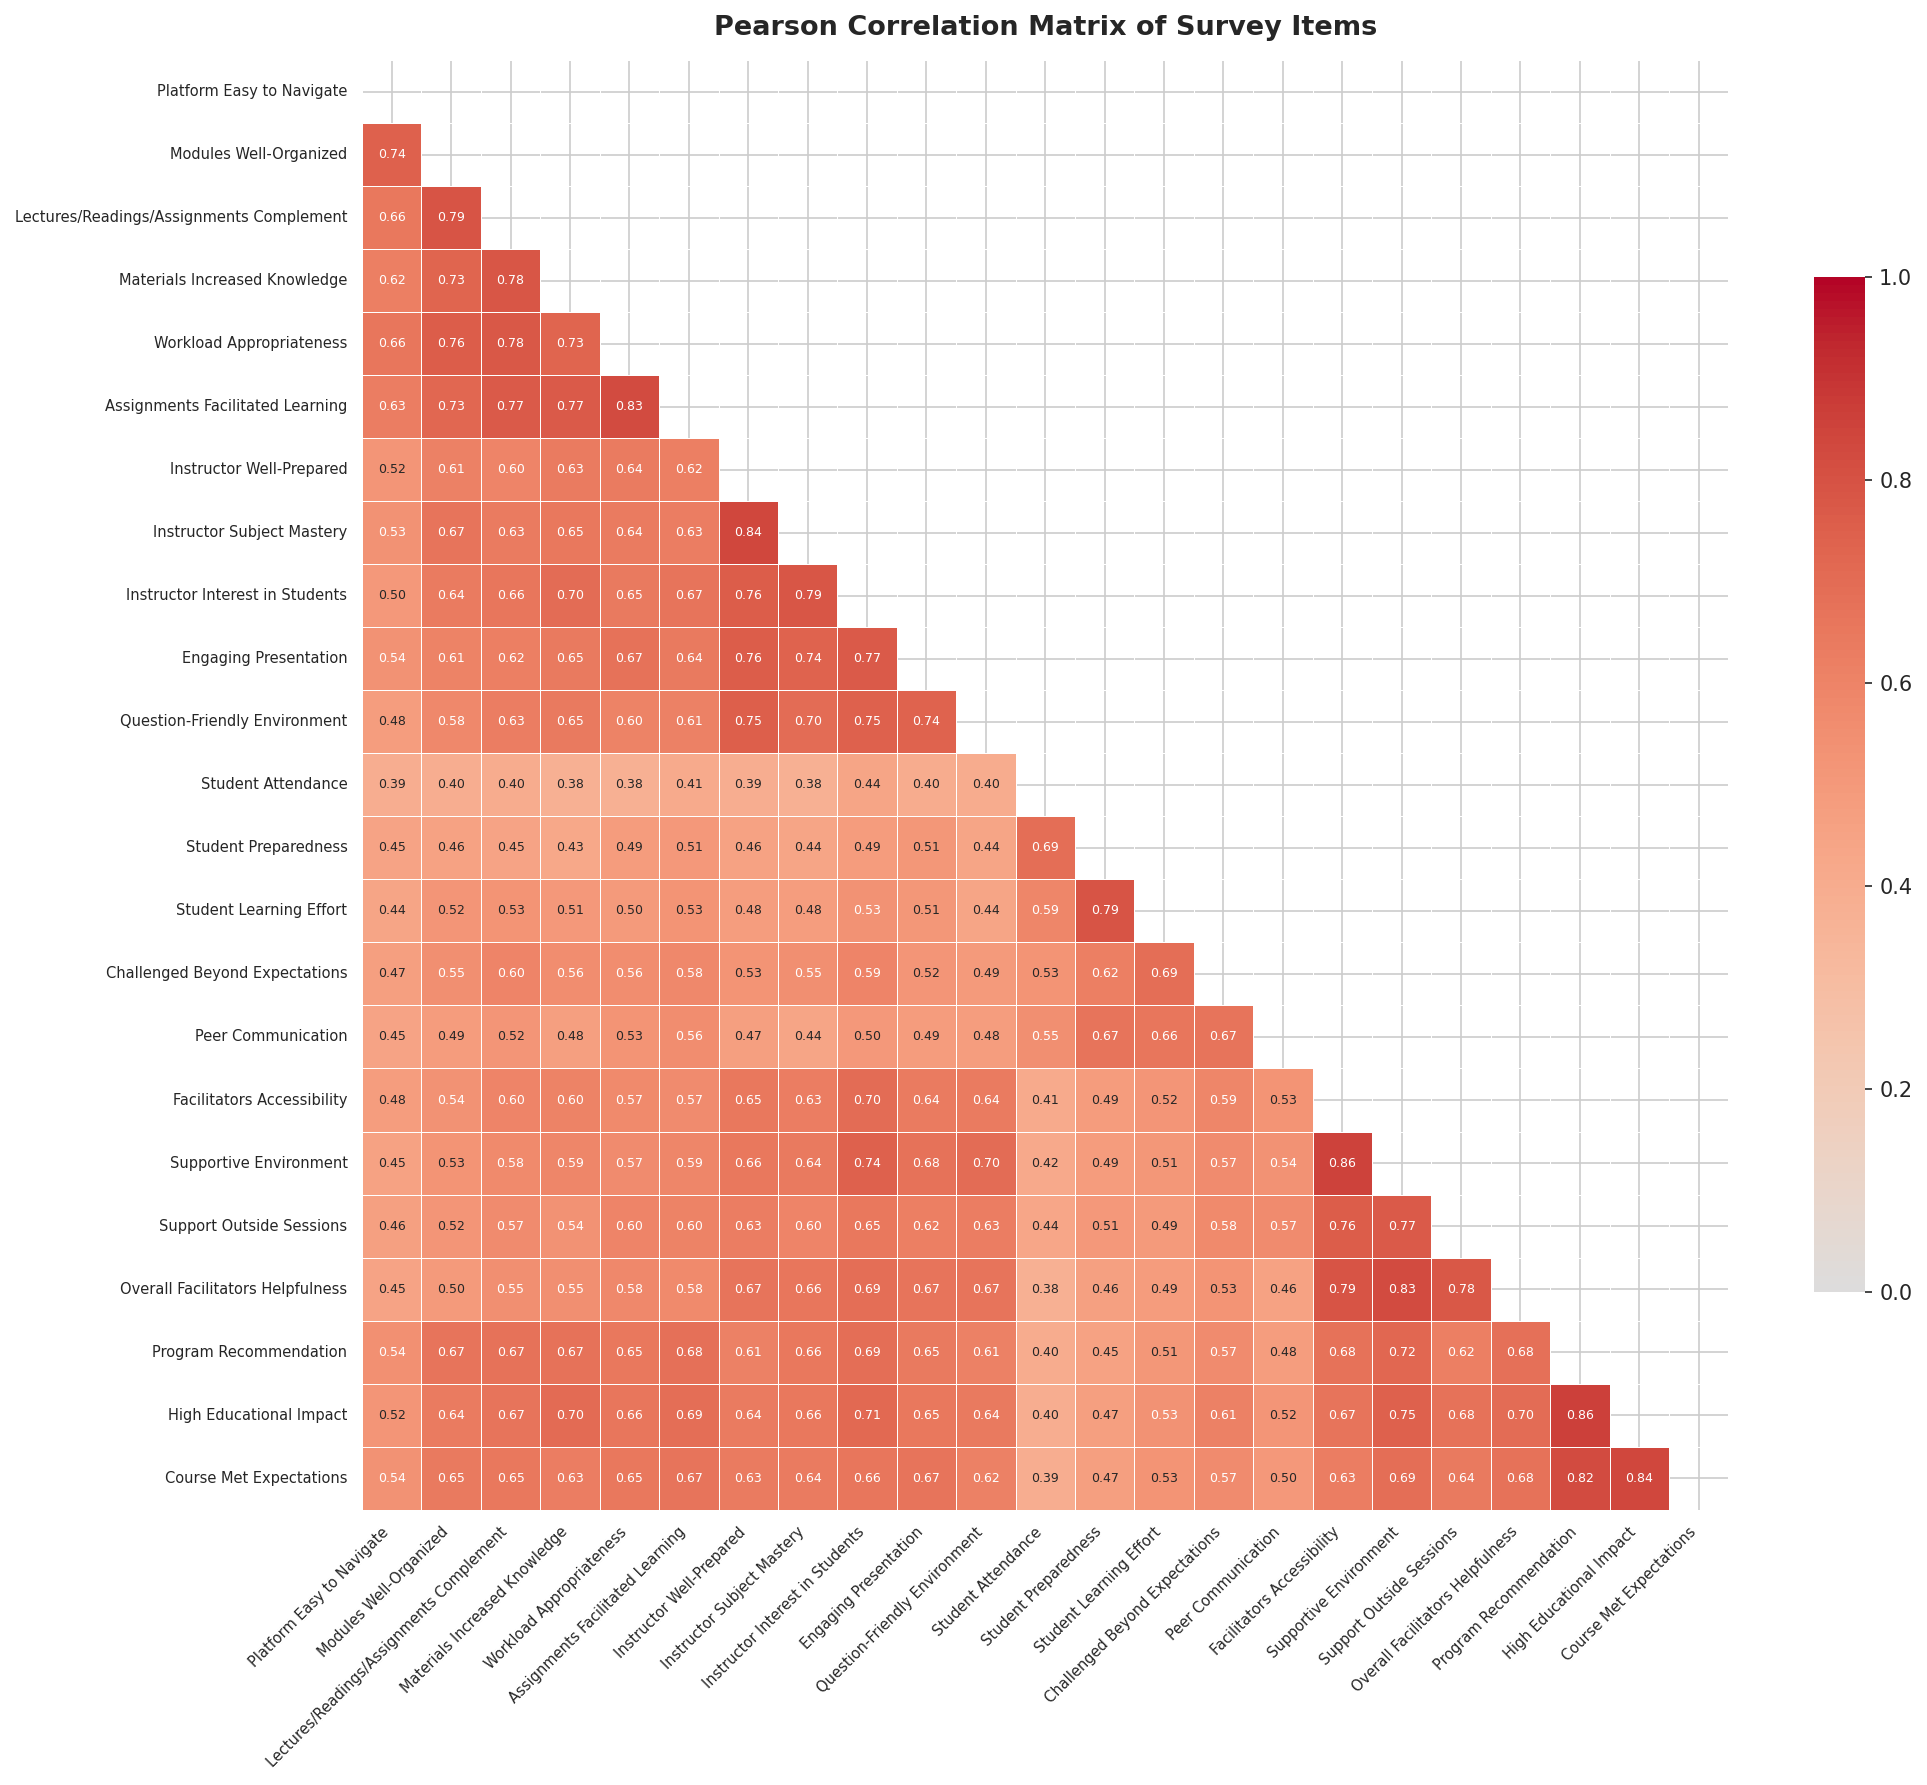

In [ ]:
# ==============================================================================
# CELL 20. CORRELATION HEATMAP
# ==============================================================================
corr_matrix = df_survey[RATING_COLS].corr()
short_cols  = [SHORT_LABELS[c] for c in RATING_COLS]

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, annot_kws={"size":6},
            xticklabels=short_cols, yticklabels=short_cols,
            ax=ax, vmin=0, vmax=1, cbar_kws={"shrink":0.7})
ax.set_title("Pearson Correlation Matrix of Survey Items", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"06_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ==============================================================================
# CELL 21. CRONBACH'S ALPHA — INSTRUMENT RELIABILITY
# ==============================================================================
def cronbach_alpha(data):
    data = data.dropna()
    n = data.shape[1]
    if n < 2: return np.nan
    total_var = data.sum(axis=1).var(ddof=1)
    item_var  = data.var(axis=0, ddof=1).sum()
    return (n/(n-1)) * (1 - item_var/total_var)

overall_alpha = cronbach_alpha(df_survey[RATING_COLS])

alpha_rows = [{"Category":"Overall (all items)","Cronbach α":round(overall_alpha,4),"Items":len(RATING_COLS)}]
for cat, cols in CATEGORIES.items():
    alpha_rows.append({"Category":cat,"Cronbach α":round(cronbach_alpha(df_survey[cols]),4),"Items":len(cols)})

alpha_table = pd.DataFrame(alpha_rows)
print("Reliability Analysis (Cronbach's Alpha):")
print(alpha_table.to_string(index=False))


Reliability Analysis (Cronbach's Alpha):
            Category  Cronbach α  Items
 Overall (all items)      0.9691     23
  Platform & Content      0.9409      6
  Instructor Quality      0.9393      5
  Student Engagement      0.9006      5
 Facilitator Support      0.9384      4
Overall Satisfaction      0.9388      3


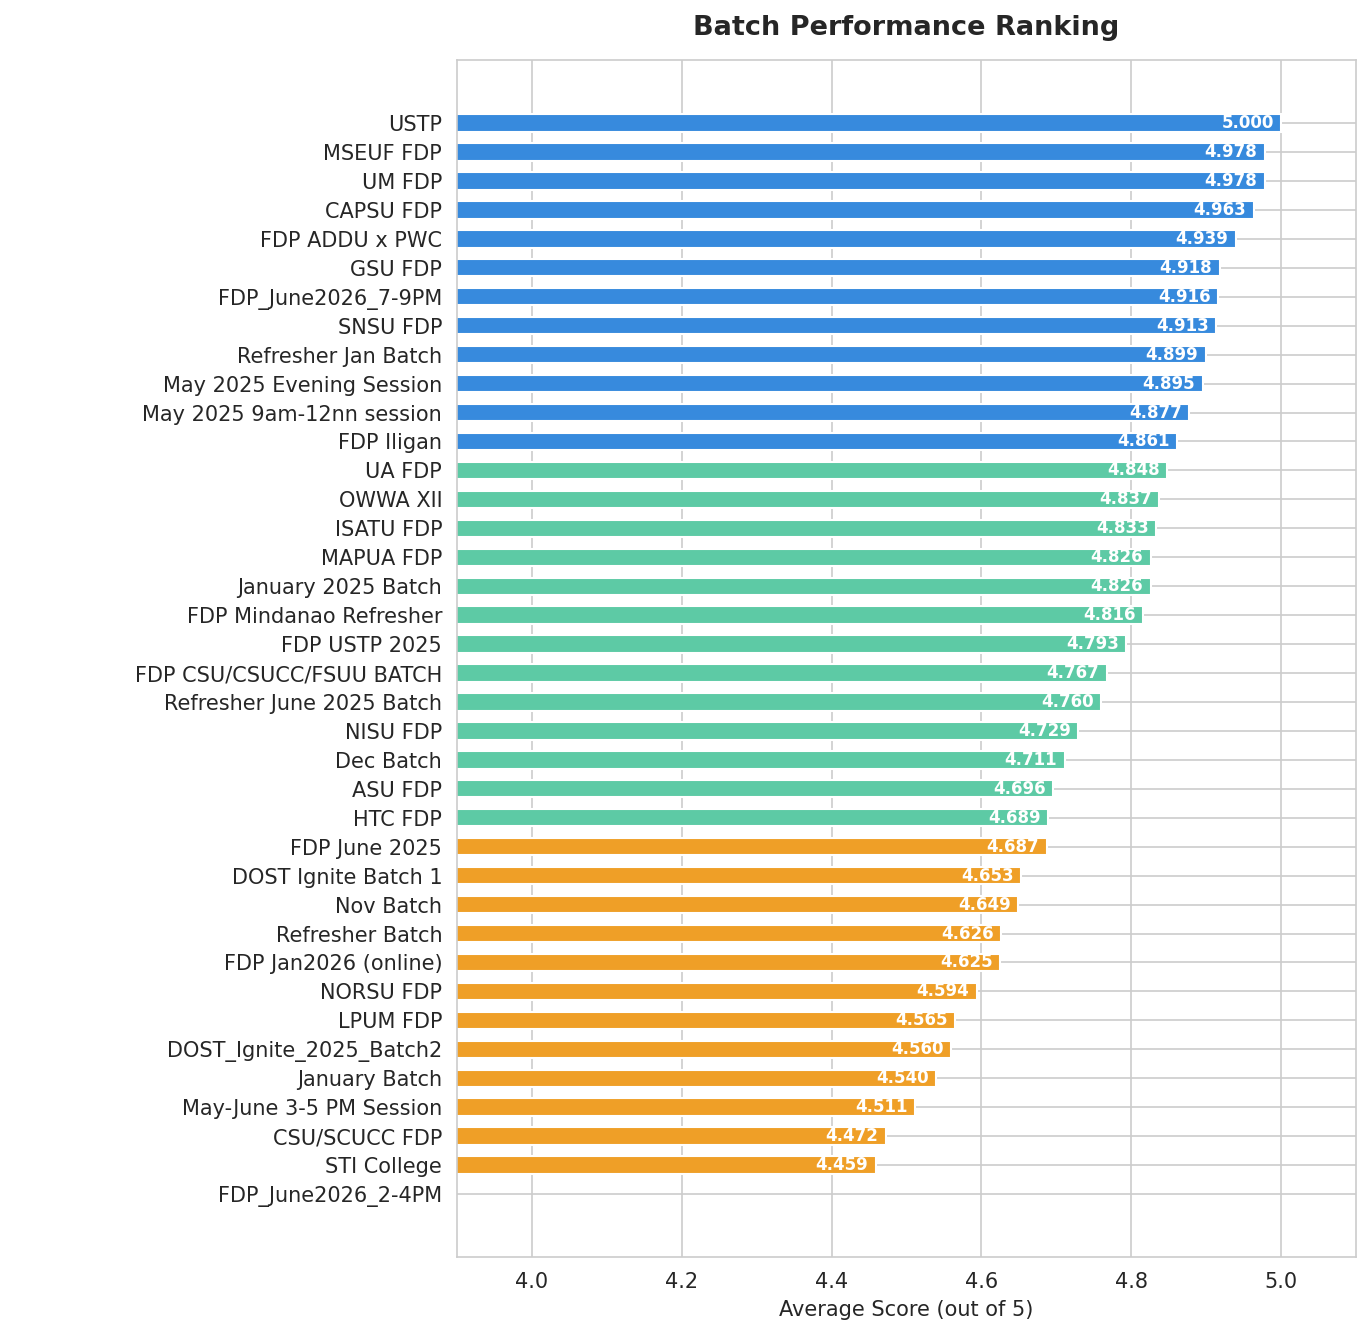

In [ ]:
# ==============================================================================
# CELL 22. BATCH-LEVEL PERFORMANCE RANKING
# ==============================================================================
batch_scores = (
    df_survey.groupby(BATCH_COL)[RATING_COLS].mean().mean(axis=1)
    .sort_values(ascending=False)
    .reset_index()
)
batch_scores.columns = ["Batch","Average Score"]
batch_scores["Average Score"] = batch_scores["Average Score"].round(3)
batch_scores.index = range(1, len(batch_scores)+1)
batch_scores.index.name = "Rank"

fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = ["#378ADD" if i < len(batch_scores)//3
              else "#5DCAA5" if i < 2*len(batch_scores)//3
              else "#EF9F27" for i in range(len(batch_scores))]
ax.barh(batch_scores["Batch"], batch_scores["Average Score"], color=bar_colors, edgecolor="white", height=0.6)
for i, (_, row) in enumerate(batch_scores.iterrows()):
    ax.text(row["Average Score"]-0.01, i, f"{row['Average Score']:.3f}",
            va="center", ha="right", color="white", fontweight="bold", fontsize=8)
ax.set_xlim(3.9, 5.1)
ax.set_xlabel("Average Score (out of 5)", fontsize=10)
ax.set_title("Batch Performance Ranking", fontsize=13, fontweight="bold", pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"07_batch_ranking.png"), dpi=300, bbox_inches="tight")
plt.show()


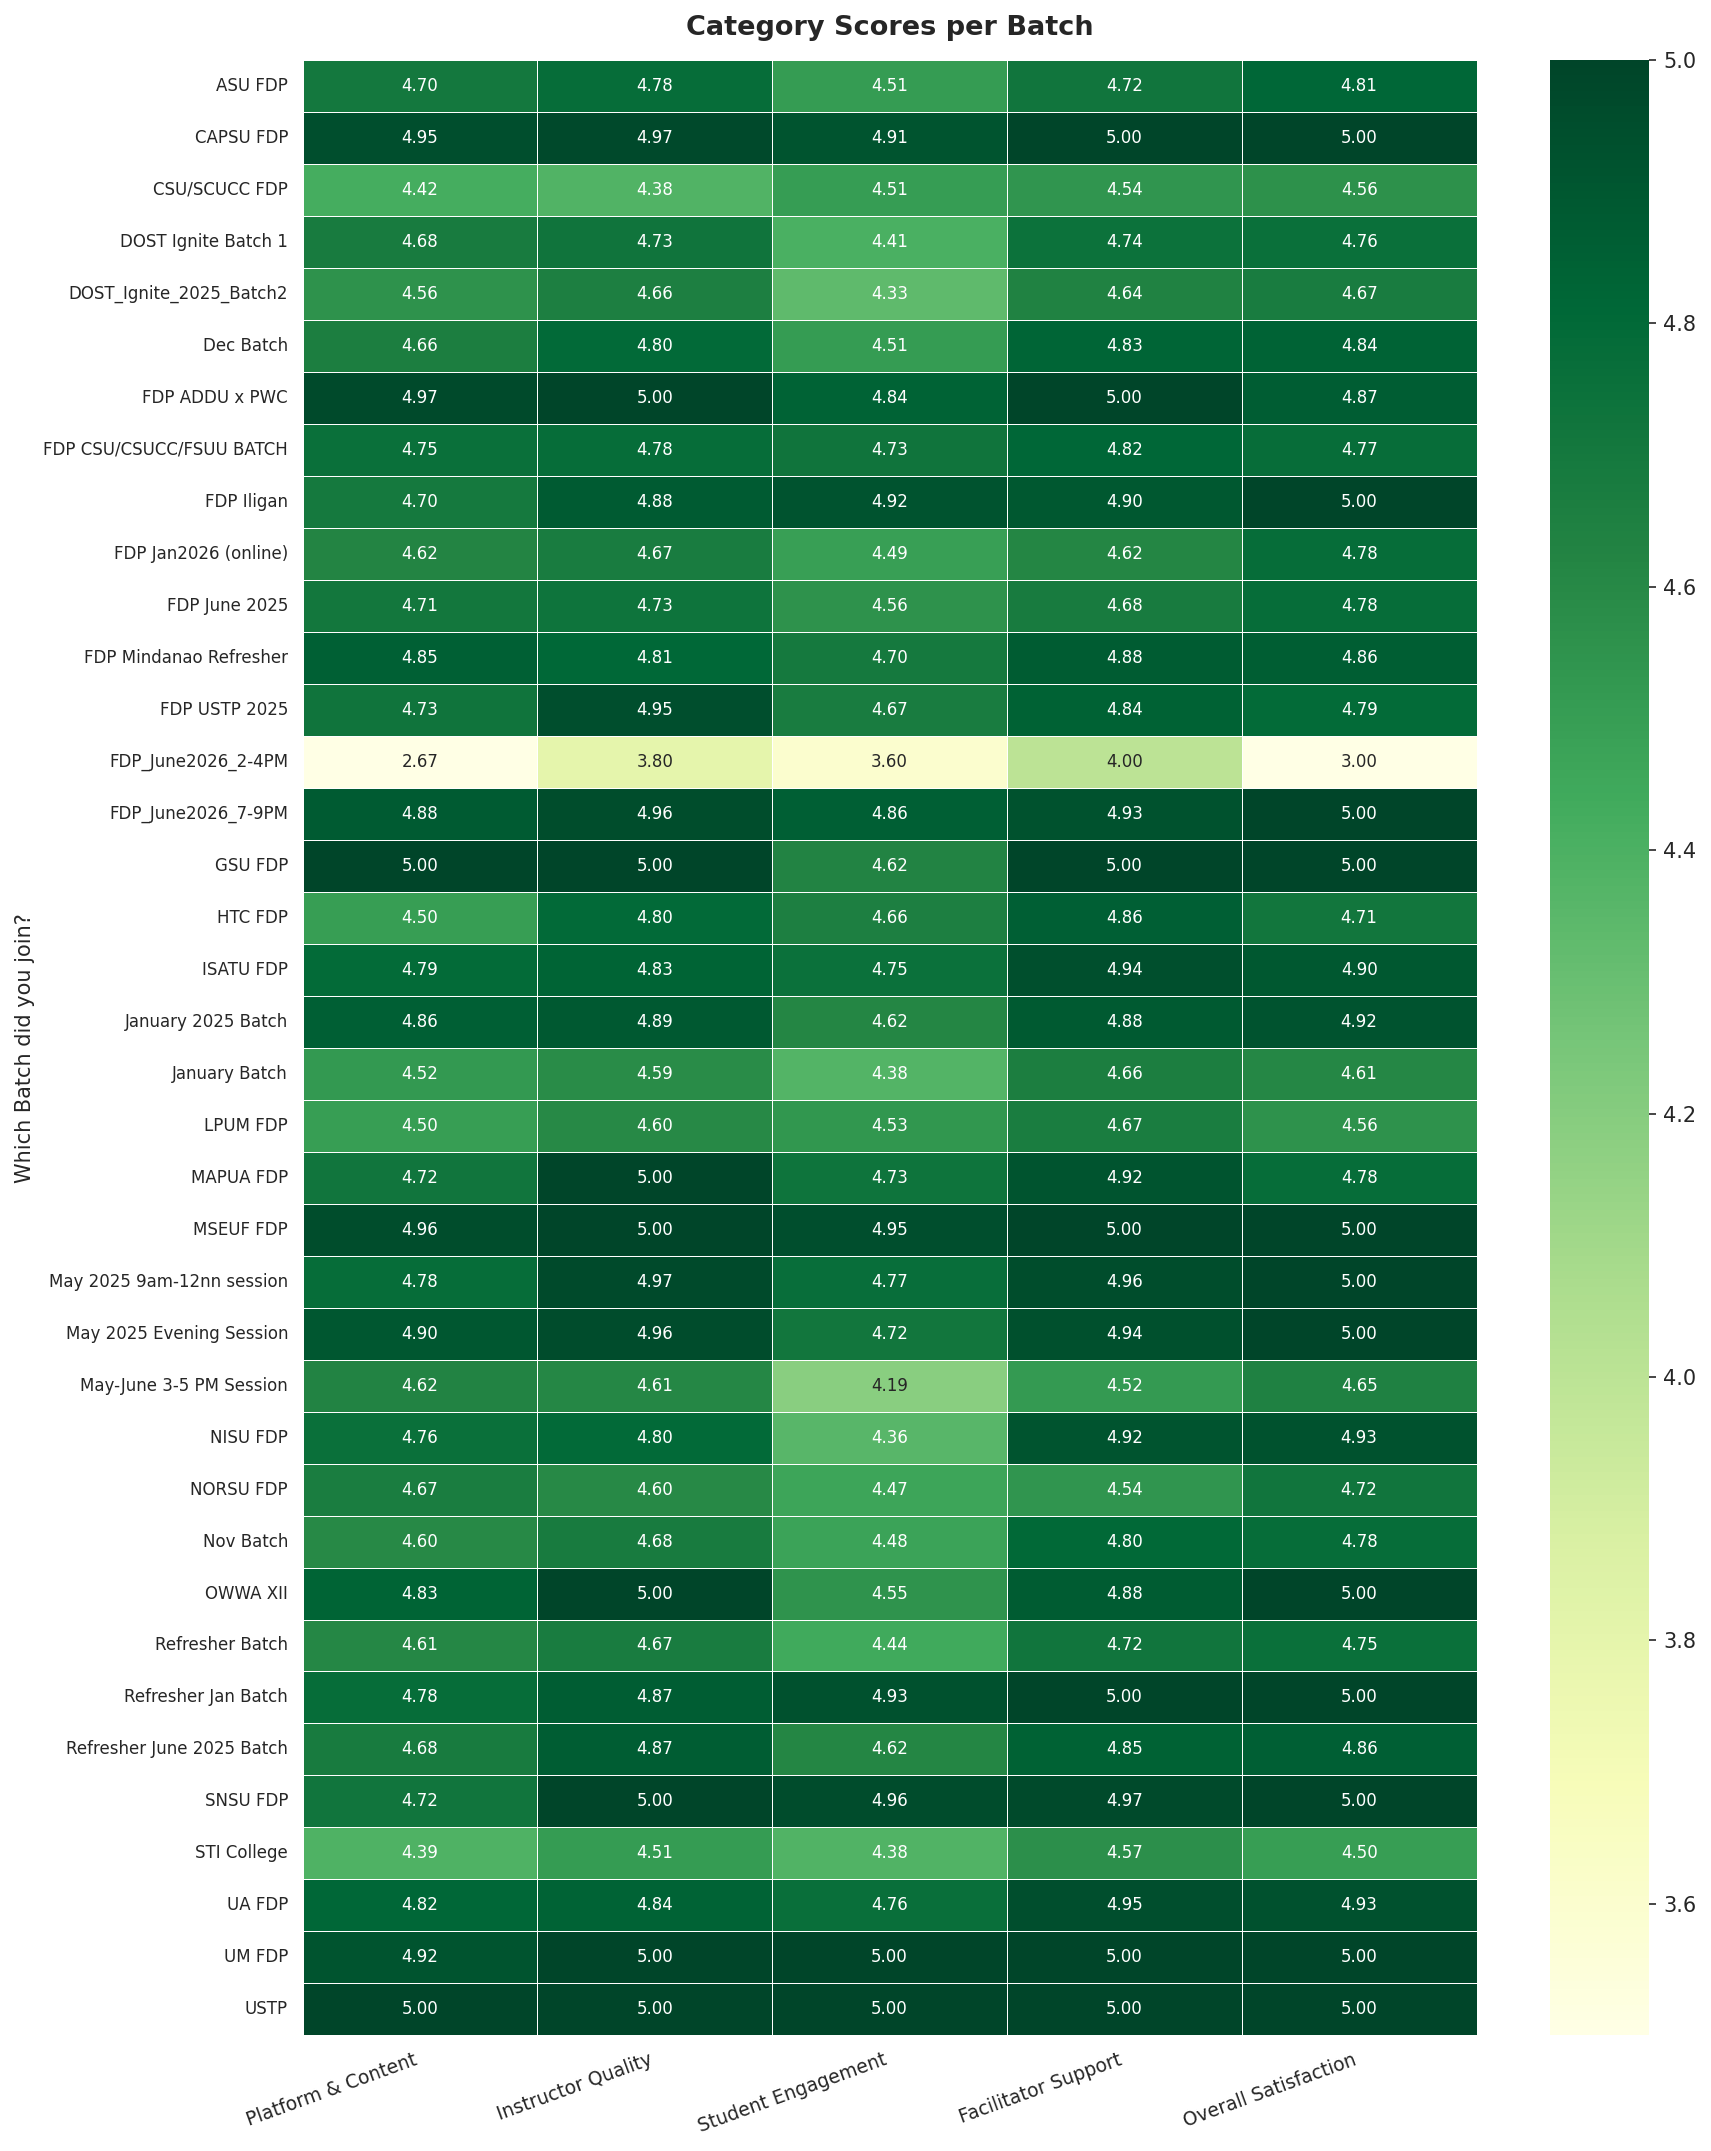

In [ ]:
# ==============================================================================
# CELL 23. BATCH × CATEGORY HEATMAP
# ==============================================================================
batch_cat_scores = pd.DataFrame({
    cat: df_survey.groupby(BATCH_COL)[cols].mean().mean(axis=1)
    for cat, cols in CATEGORIES.items()
})

fig, ax = plt.subplots(figsize=(12, max(6, len(batch_cat_scores)*0.38)))
sns.heatmap(batch_cat_scores, annot=True, fmt=".2f", cmap="YlGn",
            linewidths=0.4, annot_kws={"size":8}, vmin=3.5, vmax=5.0, ax=ax)
ax.set_title("Category Scores per Batch", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"08_batch_category_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ==============================================================================
# CELL 24. YEAR-OVER-YEAR COMPARISON: 2024 vs 2025 vs 2026 — ITEM LEVEL
#
# Now that all batches are properly assigned to a year via the faculty master
# list, this comparison is accurate and complete. 2024 has a small sample
# (Nov Batch only, n=6) so interpret with caution.
# ==============================================================================
period_df    = df_survey[df_survey["Period"].isin(["2024","2025","2026"])].copy()
period_means = period_df.groupby("Period")[RATING_COLS].mean()

yoy_table = pd.DataFrame({
    "Short Label": [SHORT_LABELS[c] for c in RATING_COLS],
    "Mean 2024"  : period_means.loc["2024", RATING_COLS].values.round(3)
                   if "2024" in period_means.index else [None]*len(RATING_COLS),
    "Mean 2025"  : period_means.loc["2025", RATING_COLS].values.round(3),
    "Mean 2026"  : period_means.loc["2026", RATING_COLS].values.round(3),
})
yoy_table["2025 → 2026"] = (yoy_table["Mean 2026"] - yoy_table["Mean 2025"]).round(3)
yoy_table["Direction"] = yoy_table["2025 → 2026"].apply(
    lambda x: "▲ Improved" if x > 0.01 else ("▼ Declined" if x < -0.01 else "→ Stable")
)

print(f"Respondents by Period:")
print(period_df["Period"].value_counts().sort_index().to_string())
print()
print("Year-over-Year Item Comparison:")
print(yoy_table.to_string(index=False))


Respondents by Period:
Period
2024      6
2025    449
2026    216

Year-over-Year Item Comparison:
                             Short Label  Mean 2024  Mean 2025  Mean 2026  2025 → 2026  Direction
               Platform Easy to Navigate      4.667      4.653      4.528       -0.125 ▼ Declined
                  Modules Well-Organized      5.000      4.675      4.630       -0.045 ▼ Declined
Lectures/Readings/Assignments Complement      5.000      4.733      4.676       -0.057 ▼ Declined
           Materials Increased Knowledge      5.000      4.766      4.736       -0.030 ▼ Declined
                Workload Appropriateness      4.667      4.655      4.602       -0.053 ▼ Declined
        Assignments Facilitated Learning      5.000      4.677      4.639       -0.038 ▼ Declined
                Instructor Well-Prepared      5.000      4.762      4.718       -0.044 ▼ Declined
              Instructor Subject Mastery      5.000      4.782      4.741       -0.041 ▼ Declined
         Instructor

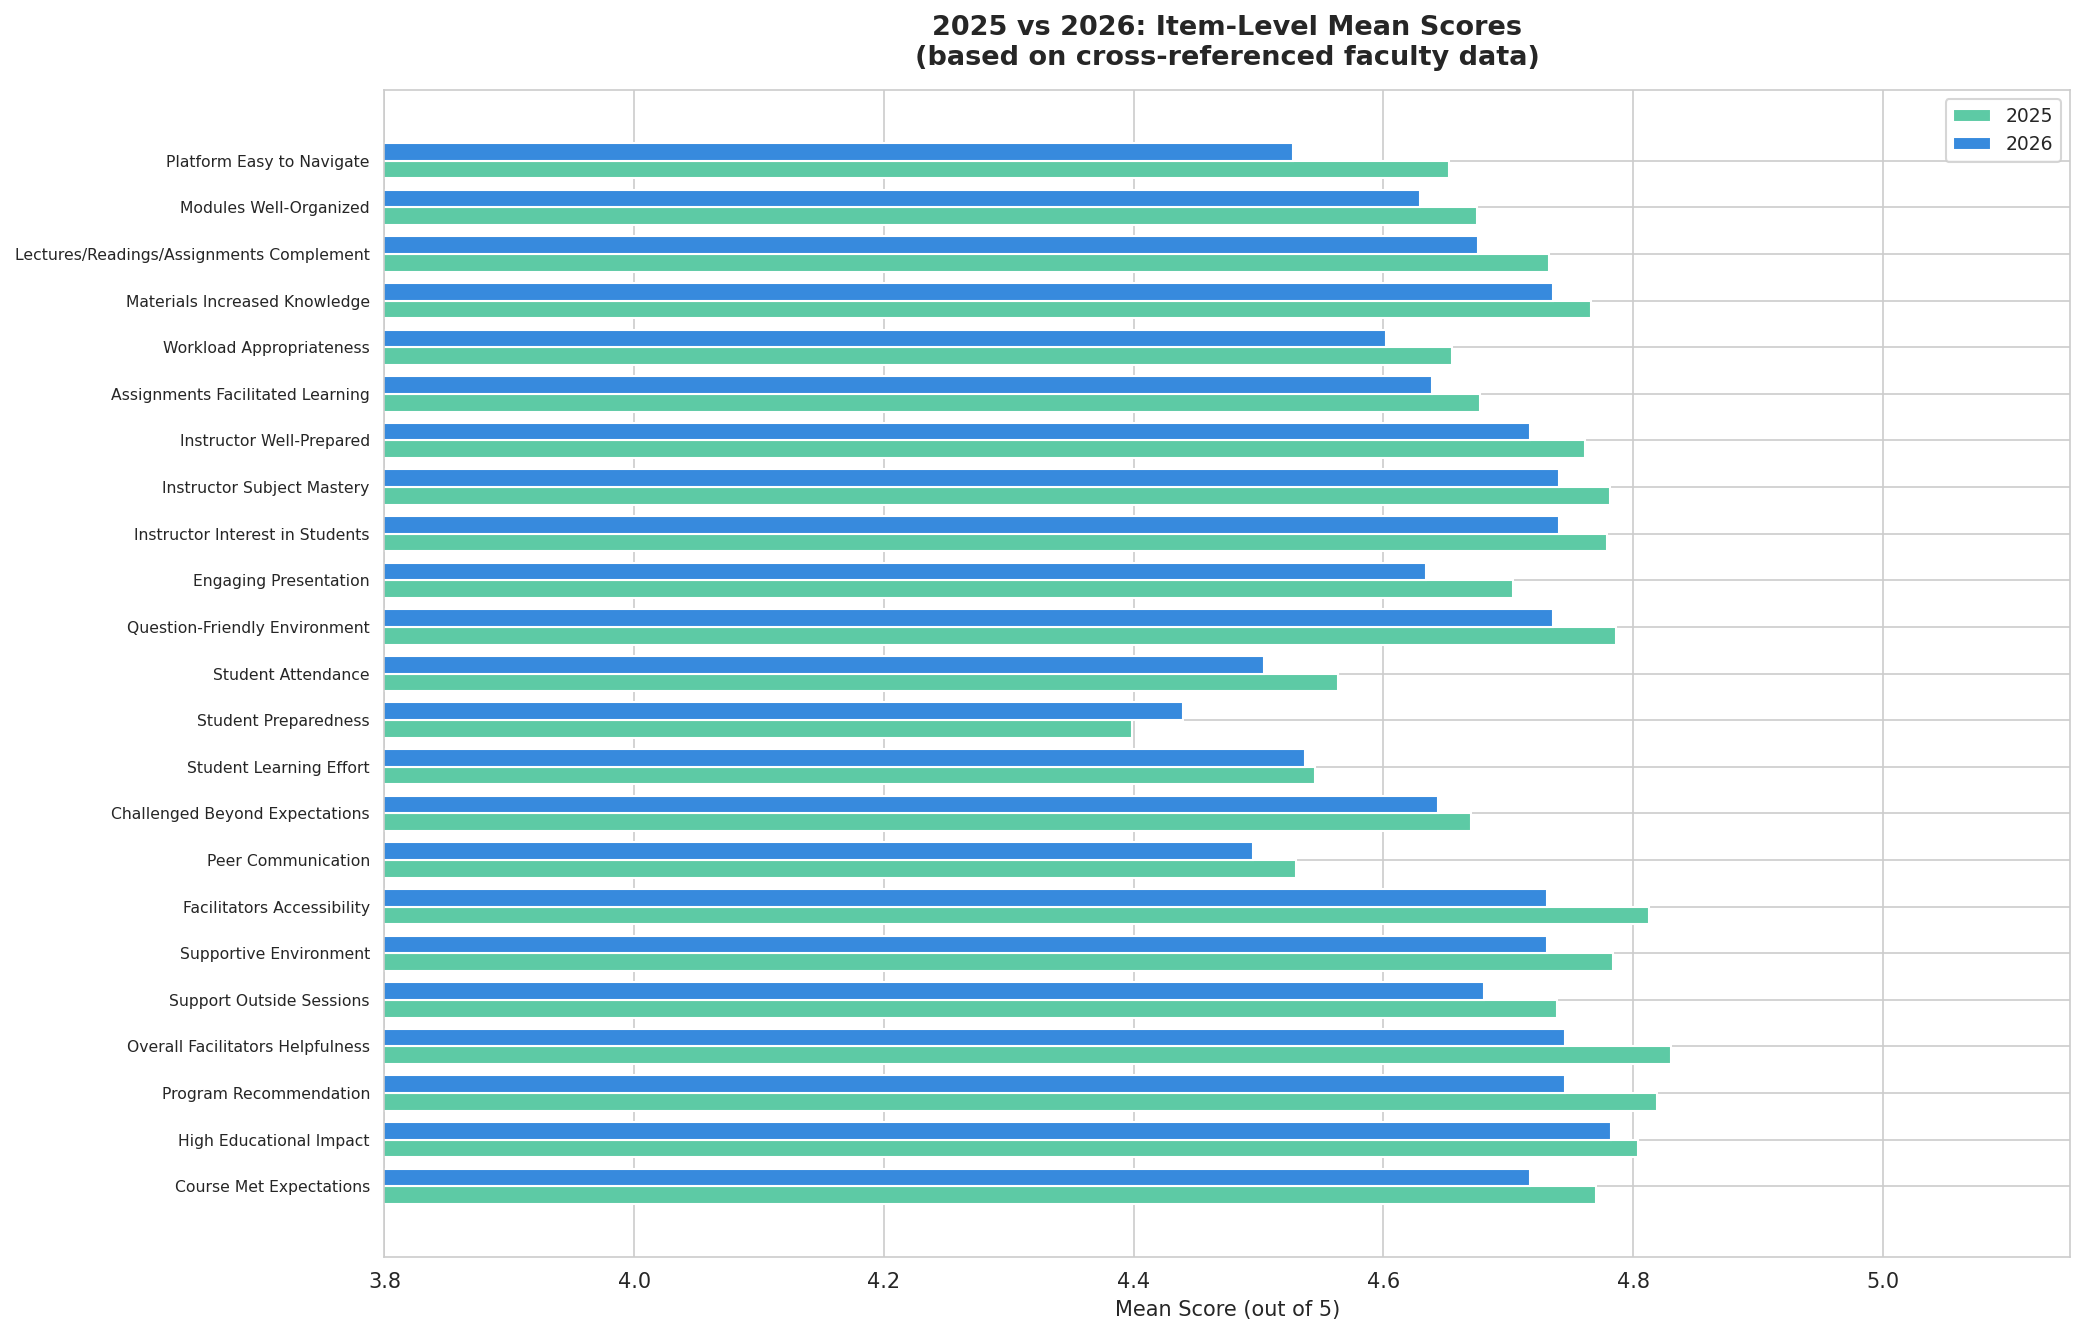

In [ ]:
# ==============================================================================
# CELL 25. YEAR-OVER-YEAR BAR CHART — ITEM LEVEL (2025 vs 2026)
# ==============================================================================
x        = np.arange(len(RATING_COLS))
width    = 0.38
labels   = [SHORT_LABELS[c] for c in RATING_COLS]
means_25 = period_means.loc["2025", RATING_COLS].values
means_26 = period_means.loc["2026", RATING_COLS].values

fig, ax = plt.subplots(figsize=(14, 9))
ax.barh(x+width/2, means_25, width, label="2025", color="#5DCAA5", edgecolor="white")
ax.barh(x-width/2, means_26, width, label="2026", color="#378ADD", edgecolor="white")
ax.set_yticks(x)
ax.set_yticklabels(labels, fontsize=7.5)
ax.set_xlim(3.8, 5.15)
ax.set_xlabel("Mean Score (out of 5)", fontsize=10)
ax.set_title("2025 vs 2026: Item-Level Mean Scores\n(based on cross-referenced faculty data)", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"09_yoy_item_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ==============================================================================
# CELL 26. YEAR-OVER-YEAR — CATEGORY LEVEL WITH WELCH'S T-TEST
# ==============================================================================
yoy_cat_rows = []
for cat, cols in CATEGORIES.items():
    g25 = period_df[period_df["Period"]=="2025"][cols].mean(axis=1).dropna()
    g26 = period_df[period_df["Period"]=="2026"][cols].mean(axis=1).dropna()
    t_stat, p_val = ttest_ind(g25, g26, equal_var=False)
    yoy_cat_rows.append({
        "Category"            : cat,
        "n (2025)"            : len(g25),
        "n (2026)"            : len(g26),
        "Mean 2025"           : round(g25.mean(), 3),
        "Mean 2026"           : round(g26.mean(), 3),
        "Change"              : round(g26.mean()-g25.mean(), 3),
        "t-statistic"         : round(t_stat, 3),
        "p-value"             : round(p_val, 4),
        "Significant (p<0.05)": "Yes" if p_val < 0.05 else "No",
    })

yoy_cat_table = pd.DataFrame(yoy_cat_rows)
print("Category Year-over-Year Comparison with Welch's t-Test:")
print(yoy_cat_table.to_string(index=False))


Category Year-over-Year Comparison with Welch's t-Test:
            Category  n (2025)  n (2026)  Mean 2025  Mean 2026  Change  t-statistic  p-value Significant (p<0.05)
  Platform & Content       449       216      4.693      4.635  -0.058        1.231   0.2190                   No
  Instructor Quality       449       216      4.763      4.714  -0.049        1.150   0.2510                   No
  Student Engagement       449       216      4.542      4.524  -0.018        0.352   0.7250                   No
 Facilitator Support       449       216      4.792      4.722  -0.070        1.540   0.1246                   No
Overall Satisfaction       449       216      4.798      4.748  -0.050        1.133   0.2578                   No


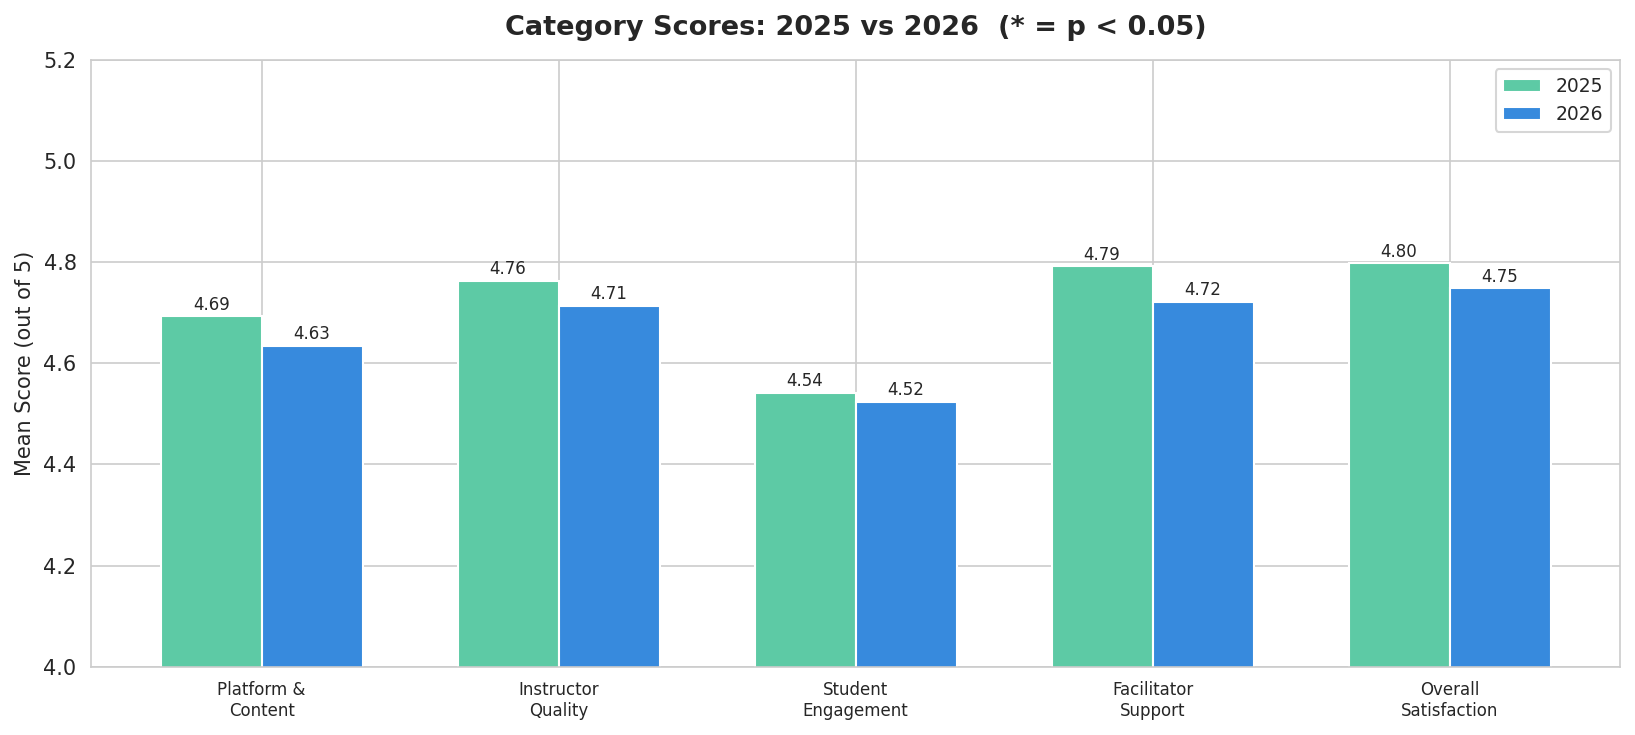

In [ ]:
# ==============================================================================
# CELL 27. YEAR-OVER-YEAR CATEGORY BAR CHART (* = statistically significant)
# ==============================================================================
cats  = yoy_cat_table["Category"].tolist()
m25   = yoy_cat_table["Mean 2025"].values
m26   = yoy_cat_table["Mean 2026"].values
sig   = yoy_cat_table["Significant (p<0.05)"].values
x     = np.arange(len(cats))
width = 0.34

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x-width/2, m25, width, label="2025", color="#5DCAA5", edgecolor="white")
ax.bar(x+width/2, m26, width, label="2026", color="#378ADD", edgecolor="white")

for xi, (v25, v26, s) in enumerate(zip(m25, m26, sig)):
    ax.text(xi-width/2, v25+0.005, f"{v25:.2f}", ha="center", va="bottom", fontsize=8)
    ax.text(xi+width/2, v26+0.005, f"{v26:.2f}" + (" *" if s=="Yes" else ""), ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels([textwrap.fill(c,14) for c in cats], fontsize=8)
ax.set_ylim(4.0, 5.2)
ax.set_ylabel("Mean Score (out of 5)", fontsize=10)
ax.set_title("Category Scores: 2025 vs 2026  (* = p < 0.05)", fontsize=13, fontweight="bold", pad=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"10_yoy_category_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ==============================================================================
# CELL 28. OPEN-ENDED TEXT — EXTRACT AND CLEAN
# ==============================================================================
def clean_text_series(col_name):
    s = df_survey[col_name].dropna().astype(str).str.strip()
    return s[~s.str.lower().isin(JUNK)].reset_index(drop=True)

best_aspects = clean_text_series(OPEN_ENDED["best_aspects"])
improvements = clean_text_series(OPEN_ENDED["improvements"])
suggestions  = clean_text_series(OPEN_ENDED["suggestions"])

print(f"Valid 'Best Aspects' responses : {len(best_aspects)}")
print(f"Valid 'Improvements' responses : {len(improvements)}")
print(f"Valid 'Suggestions' responses  : {len(suggestions)}")


Valid 'Best Aspects' responses : 635
Valid 'Improvements' responses : 612
Valid 'Suggestions' responses  : 196


In [ ]:
# ==============================================================================
# CELL 29. SAMPLE OPEN-ENDED RESPONSES BY YEAR (2025 vs 2026)
#
# Provides qualitative evidence of feedback changes between training years.
# These excerpts are used in the paper to support quantitative findings.
# ==============================================================================
for period in ["2025","2026"]:
    sub = df_survey[df_survey["Period"]==period]
    n   = len(sub)
    print(f"{'='*65}")
    print(f"  TRAINING YEAR {period}  (n = {n} respondents)")
    print(f"{'='*65}")

    for col_label, col in [
        ("BEST ASPECTS", OPEN_ENDED["best_aspects"]),
        ("AREAS TO IMPROVE", OPEN_ENDED["improvements"]),
        ("SUGGESTIONS", OPEN_ENDED["suggestions"]),
    ]:
        responses = sub[col].dropna().astype(str).str.strip()
        responses = responses[~responses.str.lower().isin(JUNK)]
        print(f"\n  [{col_label}]  ({len(responses)} valid responses)")
        for i, r in enumerate(responses.head(5), 1):
            wrapped = textwrap.fill(r, width=90, initial_indent="    ", subsequent_indent="       ")
            print(f"    {i}. {wrapped.strip()}")
    print()


  TRAINING YEAR 2025  (n = 449 respondents)

  [BEST ASPECTS]  (426 valid responses)
    1. The best aspects of the FDP were its innovative pedagogy, hands-on learning,
       collaborative environment, expert mentorship, and technology integration, all of
       which enhanced teaching effectiveness and student engagement.
    2. The venture journey wherein we were to come up with innovative ideas that has a
       possibility to be a startup company
    3. Knowing the customer persona
    4. The Platform
    5. The diligent and knowledgeable facilitators, for me. They made the whole training a
       step further.

  [AREAS TO IMPROVE]  (407 valid responses)
    1. Please consider contextualizing the samples and lesson discussions on the platform to
       better align with the Philippine setting, as some examples currently reflect the
       Indian context.
    2. Wadhwani Platform Navigation
    3. Wadhwani Platform Navigation, Class Experience
    4. Wadhwani Platform Navigation
 

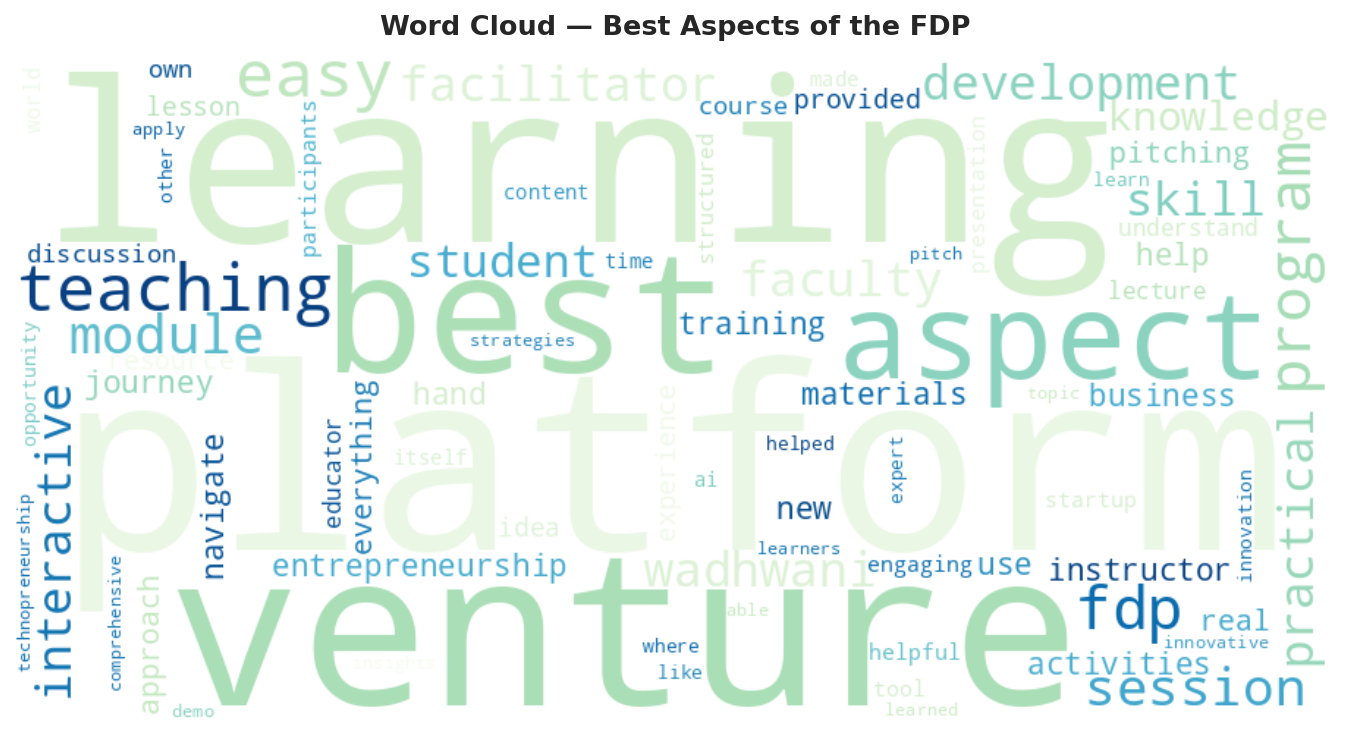

In [ ]:
# ==============================================================================
# CELL 30. WORD CLOUD — BEST ASPECTS
# ==============================================================================
STOP_WORDS = {
    "the","and","a","an","of","to","in","for","is","was","it","that","this",
    "with","are","as","at","be","by","from","on","we","i","my","our","have",
    "has","had","were","been","their","they","also","very","more","so","me",
    "which","what","how","all","but","or","its","would","could","not","no",
    "us","well","can","really","much","great",
}

best_text = " ".join(best_aspects.tolist()).lower()
wc = WordCloud(width=900, height=450, background_color="white",
               stopwords=STOP_WORDS, colormap="GnBu", max_words=80, collocations=False)
wc.generate(best_text)

fig, ax = plt.subplots(figsize=(12,5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Best Aspects of the FDP", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"11_wordcloud_best_aspects.png"), dpi=300, bbox_inches="tight")
plt.show()


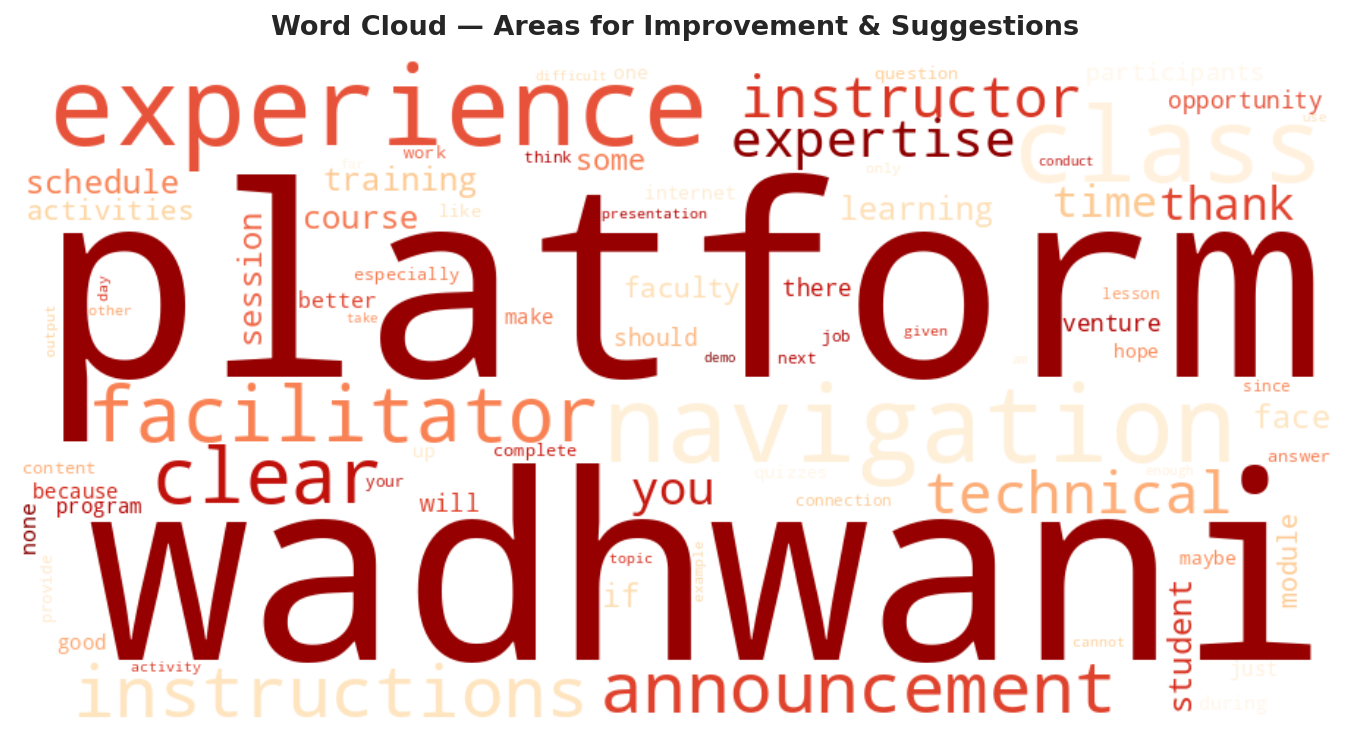

In [ ]:
# ==============================================================================
# CELL 31. WORD CLOUD — IMPROVEMENT SUGGESTIONS
# ==============================================================================
improve_text = " ".join(improvements.tolist() + suggestions.tolist()).lower()
wc2 = WordCloud(width=900, height=450, background_color="white",
                stopwords=STOP_WORDS, colormap="OrRd", max_words=80, collocations=False)
wc2.generate(improve_text)

fig, ax = plt.subplots(figsize=(12,5))
ax.imshow(wc2, interpolation="bilinear")
ax.axis("off")
ax.set_title("Word Cloud — Areas for Improvement & Suggestions", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"12_wordcloud_improvements.png"), dpi=300, bbox_inches="tight")
plt.show()


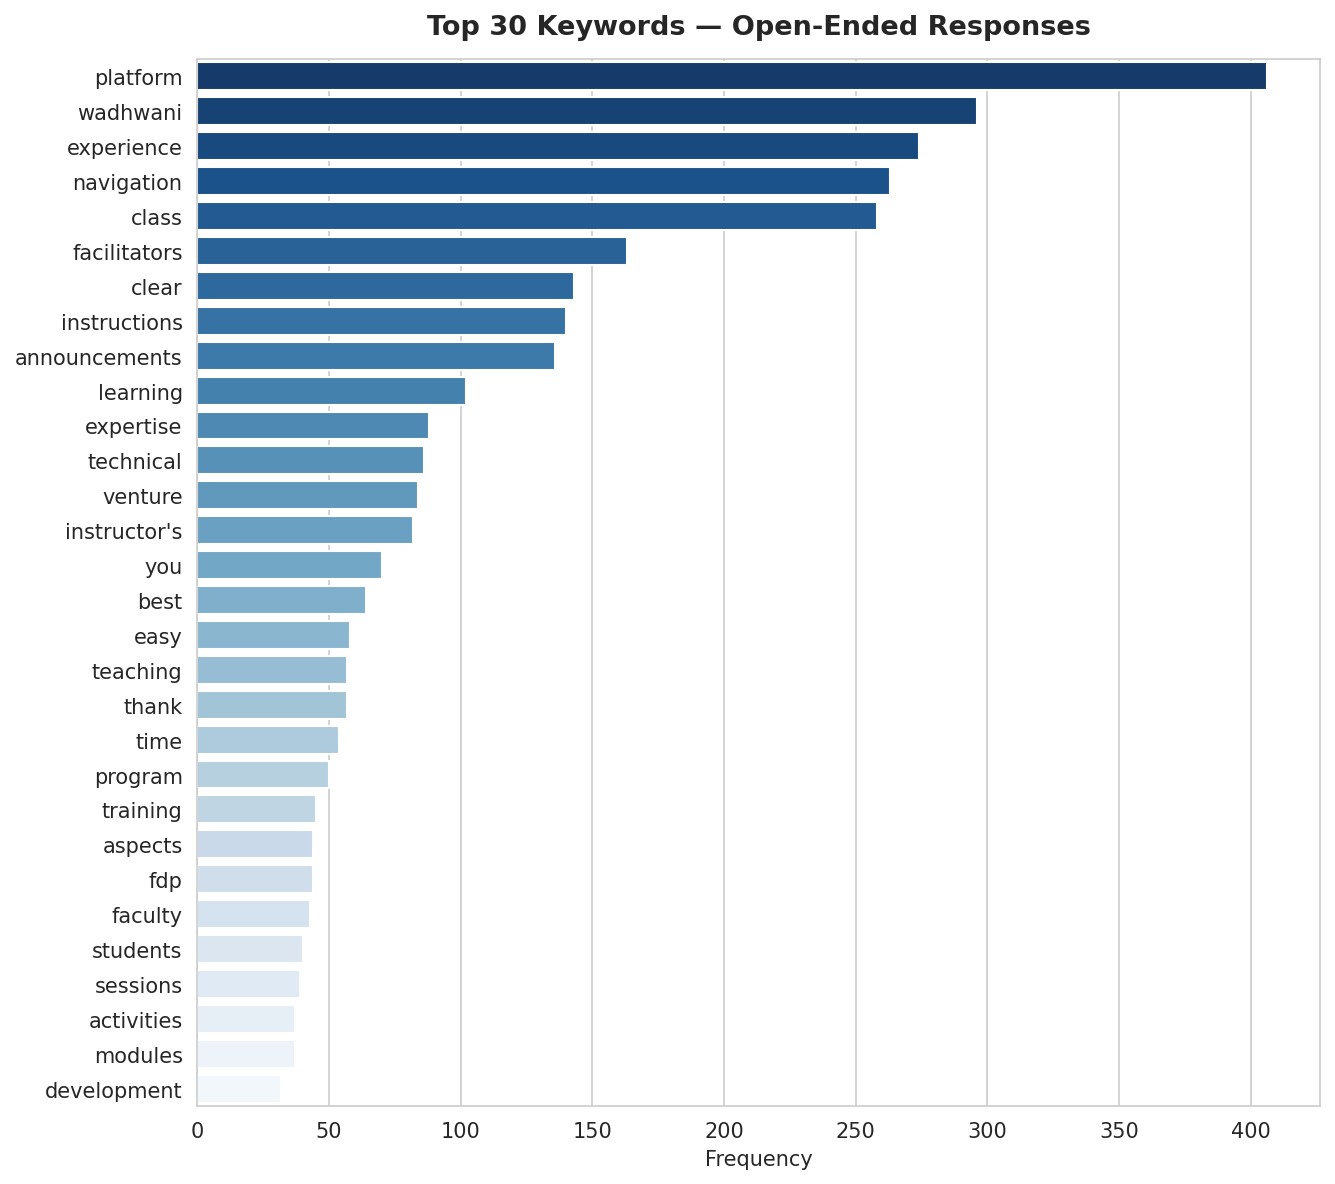

In [ ]:
# ==============================================================================
# CELL 32. KEYWORD FREQUENCY — TOP 30 WORDS
# ==============================================================================
all_text = " ".join(best_aspects.tolist()+improvements.tolist()+suggestions.tolist()).lower()
tokens = [w.strip(".,!?;:'\"()[]") for w in all_text.split()
          if w.strip(".,!?;:'\"()[]") not in STOP_WORDS and len(w.strip(".,!?;:'\"()[]")) > 2]

word_freq_df = pd.DataFrame(Counter(tokens).most_common(30), columns=["Word","Frequency"])

fig, ax = plt.subplots(figsize=(9,8))
sns.barplot(data=word_freq_df, x="Frequency", y="Word", palette="Blues_r", ax=ax)
ax.set_title("Top 30 Keywords — Open-Ended Responses", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Frequency")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(CHART_DIR,"13_keyword_frequency.png"), dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# ==============================================================================
# CELL 32B. KEYWORD FREQUENCY — SEPARATED PER OPEN-ENDED QUESTION
#
# Prints the top 15 keywords for each open-ended question separately.
# These frequencies are cited in the paper's qualitative analysis section
# and serve as the documented source for all keyword counts mentioned.
# ==============================================================================

def get_top_keywords(col_name, top_n=15):
    responses = df_survey[col_name].dropna().astype(str).str.strip()
    responses = responses[~responses.str.lower().isin(JUNK)]
    text = " ".join(responses.tolist()).lower()
    tokens = [
        w.strip(".,!?;:'\"()[]")
        for w in text.split()
        if w.strip(".,!?;:'\"()[]") not in STOP_WORDS
        and len(w.strip(".,!?;:'\"()[]")) > 2
    ]
    freq = pd.DataFrame(Counter(tokens).most_common(top_n), columns=["Word", "Frequency"])
    return responses, freq

print("=" * 65)
for col_label, col in [
    ("BEST ASPECTS",  OPEN_ENDED["best_aspects"]),
    ("IMPROVEMENTS",  OPEN_ENDED["improvements"]),
    ("SUGGESTIONS",   OPEN_ENDED["suggestions"]),
]:
    responses, freq = get_top_keywords(col)
    print(f"\n[{col_label}]  ({len(responses)} valid responses)")
    print(f"  Top 15 Keywords:")
    print(freq[["Word","Frequency"]].to_string(index=False))
    print()
print("=" * 65)


[BEST ASPECTS]  (635 valid responses)
  Top 15 Keywords:
       Word  Frequency
   platform        120
   learning         84
    venture         73
       best         63
   teaching         52
       easy         52
    aspects         43
        fdp         41
    program         40
development         28
interactive         28
   wadhwani         28
   sessions         28
  practical         28
  knowledge         26


[IMPROVEMENTS]  (612 valid responses)
  Top 15 Keywords:
         Word  Frequency
     platform        254
     wadhwani        249
   navigation        248
   experience        247
        class        246
        clear        136
 facilitators        136
 instructions        135
announcements        135
    expertise         79
 instructor's         78
    technical         78
         time         16
         face         12
         none          9


[SUGGESTIONS]  (196 valid responses)
  Top 15 Keywords:
       Word  Frequency
        you         58
      thank

In [ ]:
# ==============================================================================
# CELL 33. SURVEY INSTRUMENT REVIEW — REDUNDANCY AND SUGGESTED NEW QUESTIONS
#
# This analysis is intended to inform future revisions of the survey form.
# The proposed questions below are SUGGESTIONS ONLY and are not currently
# part of the instrument. They are included here as recommendations for the
# next iteration of the FDP evaluation tool.
# ==============================================================================

# ── Flag highly correlated item pairs (r > 0.85) ────────────────────────────
corr_pairs = []
corr_m = df_survey[RATING_COLS].corr()
for i, c1 in enumerate(RATING_COLS):
    for j, c2 in enumerate(RATING_COLS):
        if j <= i: continue
        r = corr_m.loc[c1, c2]
        if r > 0.85:
            corr_pairs.append({
                "Item A"        : SHORT_LABELS[c1],
                "Item B"        : SHORT_LABELS[c2],
                "r"             : round(r, 3),
                "Recommendation": "Consider merging or removing one item",
            })

if corr_pairs:
    print("Potentially Redundant Item Pairs (r > 0.85):")
    print(pd.DataFrame(corr_pairs).to_string(index=False))
else:
    print("No item pairs with r > 0.85 found.")

print()

# ── Proposed new questions (for future survey versions) ──────────────────────
new_questions = pd.DataFrame([
    {"Category":"Platform & Content",
     "Proposed Item":"The examples and case studies in the platform were relevant to the Philippine educational context.",
     "Rationale":"Participants in both 2025 and 2026 consistently raised concerns about Indian-context examples."},
    {"Category":"Platform & Content",
     "Proposed Item":"The online delivery format (synchronous/asynchronous) was effective for this type of training.",
     "Rationale":"Online batches (e.g., FDP Jan2026) are growing; delivery mode is not currently measured."},
    {"Category":"Student Engagement",
     "Proposed Item":"I was able to immediately apply the concepts from this training in my classroom or workplace.",
     "Rationale":"Transfer of learning to actual practice is a core FDP goal currently absent from the instrument."},
    {"Category":"Overall Satisfaction",
     "Proposed Item":"I feel more confident integrating entrepreneurship and innovation concepts into my teaching after this programme.",
     "Rationale":"Directly measures the FDP's stated mission of building faculty teaching confidence."},
    {"Category":"Facilitator Support",
     "Proposed Item":"Feedback from the facilitators helped me improve my outputs during the programme.",
     "Rationale":"Feedback quality is distinct from general helpfulness; not currently assessed separately."},
])

print("Proposed New Survey Questions (for future FDP survey versions):")
print(new_questions.to_string(index=False))


Potentially Redundant Item Pairs (r > 0.85):
                    Item A                  Item B     r                        Recommendation
Facilitators Accessibility  Supportive Environment 0.855 Consider merging or removing one item
    Program Recommendation High Educational Impact 0.863 Consider merging or removing one item

Proposed New Survey Questions (for future FDP survey versions):
            Category                                                                                                     Proposed Item                                                                                        Rationale
  Platform & Content                The examples and case studies in the platform were relevant to the Philippine educational context.   Participants in both 2025 and 2026 consistently raised concerns about Indian-context examples.
  Platform & Content                    The online delivery format (synchronous/asynchronous) was effective for this type of training.       

In [ ]:
# ==============================================================================
# CELL 34. PROGRAMME RECOMMENDATIONS
# ==============================================================================
recommendations = pd.DataFrame([
    {"Priority":1,
     "Finding":"Platform navigation is the lowest-rated Platform & Content item in both years.",
     "Recommendation":"Provide a structured onboarding walkthrough or tutorial video before the training begins."},
    {"Priority":2,
     "Finding":"Student Preparedness and Attendance are the two lowest-rated items overall.",
     "Recommendation":"Send pre-session materials and reminders; introduce mandatory pre-work to prime engagement."},
    {"Priority":3,
     "Finding":"Open-ended responses in both 2025 and 2026 cite 'Indian context' examples as a concern.",
     "Recommendation":"Localise case studies to Philippine settings; collaborate with local institutions for contextual examples."},
    {"Priority":4,
     "Finding":"Peer Communication is consistently lower than facilitator-driven items.",
     "Recommendation":"Embed structured peer-learning activities (peer review, collaborative case analysis) in each module."},
    {"Priority":5,
     "Finding":"Facilitator Support shows a slight decline from 2025 to 2026, particularly for online batches.",
     "Recommendation":"Review facilitator workload for online cohorts; consider additional support staff or mentor pairing."},
    {"Priority":6,
     "Finding":"2026 batches include more online/blended formats with new concerns about clear instructions.",
     "Recommendation":"Develop a standard orientation kit for online participants covering platform use and facilitator contact channels."},
    {"Priority":7,
     "Finding":"High Educational Impact is the highest-rated item (≈4.80) and stable across all years.",
     "Recommendation":"Preserve impact-driven curriculum elements; use participant testimonials in programme marketing materials."},
])

print("Evidence-Based Programme Recommendations:")
print(recommendations.to_string(index=False))


Evidence-Based Programme Recommendations:
 Priority                                                                                        Finding                                                                                                     Recommendation
        1                 Platform navigation is the lowest-rated Platform & Content item in both years.                          Provide a structured onboarding walkthrough or tutorial video before the training begins.
        2                    Student Preparedness and Attendance are the two lowest-rated items overall.                        Send pre-session materials and reminders; introduce mandatory pre-work to prime engagement.
        3        Open-ended responses in both 2025 and 2026 cite 'Indian context' examples as a concern.         Localise case studies to Philippine settings; collaborate with local institutions for contextual examples.
        4                        Peer Communication is consistently lower than

In [ ]:
# ==============================================================================
# CELL 35. SAVE MULTI-SHEET EXCEL REPORT
# ==============================================================================
report_path = os.path.join(REPORT_DIR, "FDP_Survey_Report.xlsx")

with pd.ExcelWriter(report_path, engine="openpyxl") as writer:
    question_summary.to_excel(writer, sheet_name="Item Summary",          index=False)
    category_table.to_excel(  writer, sheet_name="Category Scores",       index=False)
    alpha_table.to_excel(     writer, sheet_name="Reliability (Alpha)",   index=False)
    batch_scores.to_excel(    writer, sheet_name="Batch Rankings")
    yoy_table.to_excel(       writer, sheet_name="YoY Item Comparison",   index=False)
    yoy_cat_table.to_excel(   writer, sheet_name="YoY Category t-Test",   index=False)
    top_strengths.to_excel(   writer, sheet_name="Top Strengths",         index=False)
    weaknesses.to_excel(      writer, sheet_name="Areas for Improvement", index=False)
    new_questions.to_excel(   writer, sheet_name="Proposed Questions",    index=False)
    recommendations.to_excel( writer, sheet_name="Recommendations",       index=False)
    best_aspects.to_frame("Response").to_excel(writer, sheet_name="Best Aspects", index=False)
    improvements.to_frame("Response").to_excel(writer, sheet_name="Improvements", index=False)
    suggestions.to_frame("Response").to_excel( writer, sheet_name="Suggestions",  index=False)
    word_freq_df.to_excel(    writer, sheet_name="Keyword Frequency",     index=False)
    df_survey[["Period", BATCH_COL]].value_counts().reset_index().to_excel(
        writer, sheet_name="Period-Batch Mapping", index=False)

print(f"Excel report saved: {report_path}")


Excel report saved: /content/drive/MyDrive/FDP Survey/outputs/reports/FDP_Survey_Report.xlsx


In [ ]:
# ==============================================================================
# CELL 36. SAVE TEXT EXECUTIVE SUMMARY
# ==============================================================================
n_2024 = (df_survey["Period"]=="2024").sum()
n_2025 = (df_survey["Period"]=="2025").sum()
n_2026 = (df_survey["Period"]=="2026").sum()
overall_change = round(
    period_means.loc["2026", RATING_COLS].mean() - period_means.loc["2025", RATING_COLS].mean(), 3
)

summary = f"""
FACULTY DEVELOPMENT PROGRAM (FDP)
POST-TRAINING SURVEY — EXECUTIVE SUMMARY
{'='*65}

Total Respondents           : {len(df_survey)}
  Training Year 2024        : {n_2024}  (Nov Batch only — interpret with caution)
  Training Year 2025        : {n_2025}
  Training Year 2026        : {n_2026}

Note: Respondents are faculty who completed the FDP and requested
certification. Period assignment was cross-referenced with the
Consolidated Faculty Master List using FDP completion dates.

Overall Survey Average      : {overall_mean:.3f} / 5.00
Cronbach's Alpha            : {overall_alpha:.4f} (excellent reliability)

CATEGORY HIGHLIGHTS
  Strongest  : {category_series.index[0]} ({category_series.iloc[0]:.3f})
  Weakest    : {category_series.index[-1]} ({category_series.iloc[-1]:.3f})

YEAR-OVER-YEAR TREND (2025 → 2026)
  Overall mean change       : {overall_change:+.3f}
  Items improved (>+0.01)   : {(yoy_table['2025 → 2026'] > 0.01).sum()}
  Items declined (<-0.01)   : {(yoy_table['2025 → 2026'] < -0.01).sum()}
  Items stable              : {((yoy_table['2025 → 2026']>=-0.01)&(yoy_table['2025 → 2026']<=0.01)).sum()}
  Statistically significant : {(yoy_cat_table['Significant (p<0.05)']=='Yes').sum()} category/ies (p < 0.05)

TOP 5 STRENGTHS
{chr(10).join(f"  {i+1}. {row['Strength']} ({row['Mean Score']:.3f})" for i, row in top_strengths.iterrows())}

TOP 5 AREAS FOR IMPROVEMENT
{chr(10).join(f"  {i+1}. {row['Area for Improvement']} ({row['Mean Score']:.3f})" for i, row in weaknesses.iterrows())}

KEY THEMES — OPEN-ENDED RESPONSES
  Best aspects  : facilitators, hands-on learning, platform, entrepreneurship
  Improvements  : platform navigation, Philippine-context examples, scheduling
  Suggestions   : localised content, flexible sessions, clearer online instructions

SURVEY INSTRUMENT NOTES
  Proposed additions : {len(new_questions)} new items (see 'Proposed Questions' sheet — for future use only)
{'='*65}
"""

summary_path = os.path.join(REPORT_DIR, "executive_summary.txt")
with open(summary_path, "w") as f:
    f.write(summary)

print(summary)
print(f"Saved: {summary_path}")



FACULTY DEVELOPMENT PROGRAM (FDP)
POST-TRAINING SURVEY — EXECUTIVE SUMMARY

Total Respondents           : 671
  Training Year 2024        : 6  (Nov Batch only — interpret with caution)
  Training Year 2025        : 449
  Training Year 2026        : 216

Note: Respondents are faculty who completed the FDP and requested
certification. Period assignment was cross-referenced with the
Consolidated Faculty Master List using FDP completion dates.

Overall Survey Average      : 4.692 / 5.00
Cronbach's Alpha            : 0.9691 (excellent reliability)

CATEGORY HIGHLIGHTS
  Strongest  : Overall Satisfaction (4.784)
  Weakest    : Student Engagement (4.539)

YEAR-OVER-YEAR TREND (2025 → 2026)
  Overall mean change       : -0.048
  Items improved (>+0.01)   : 1
  Items declined (<-0.01)   : 21
  Items stable              : 1
  Statistically significant : 0 category/ies (p < 0.05)

TOP 5 STRENGTHS
  5. Overall Facilitators Helpfulness (4.805)
  4. High Educational Impact (4.799)
  3. Program Reco

In [ ]:
# ==============================================================================
# CELL 37. ANALYSIS COMPLETE
# ==============================================================================
print("=" * 65)
print("  FDP POST-TRAINING SURVEY ANALYSIS — COMPLETE")
print("=" * 65)
print(f"  Total respondents  : {len(df_survey)}")
print(f"  Overall mean       : {overall_mean:.3f} / 5.00")
print(f"  Cronbach's alpha   : {overall_alpha:.4f}")
print(f"  Charts saved to    : {CHART_DIR}")
print(f"  Report saved to    : {REPORT_DIR}")
print("=" * 65)


  FDP POST-TRAINING SURVEY ANALYSIS — COMPLETE
  Total respondents  : 671
  Overall mean       : 4.692 / 5.00
  Cronbach's alpha   : 0.9691
  Charts saved to    : /content/drive/MyDrive/FDP Survey/outputs/charts
  Report saved to    : /content/drive/MyDrive/FDP Survey/outputs/reports
